# Load Tether Analysis Dataframe

This notebook demonstrates how to load and work with tether analysis data exported in XArray format from the PyFMGUI DyNaMo tether analysis tool.

The notebook covers:
1. Loading session data from NetCDF files
2. Loading analysis results from NetCDF files 
3. Basic data exploration and visualization
4. Working with the structured scientific data format

In [148]:
# Import required libraries
# import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from plotly.subplots import make_subplots
import plotly.graph_objects as go

import plotly.express as px



In [149]:
# open csv file as dataframe
csv_file_path = '/Users/evillz/Data/article/2025_07_01_THP1_phd/sessions/batch_analysis_results/detailed_plateau_data.csv'
csv_file_path = '/Users/evillz/Data/article/2025_07_01_THP1_phd/sessions/velocity_normalized_thp1_cell1/batch_analysis_results/detailed_plateau_data.csv'
csv_file_path = '/Users/evillz/Data/article/final_yey/batch_analysis_results/detailed_plateau_data.csv'
csv_file_path = '/Users/evillz/Data/article/final_yey/final/yess/batch_analysis_results/detailed_plateau_data.csv'

df = pd.read_csv(csv_file_path)


In [150]:
# Cycle through file_idx and plateau_idx, get delta_avg for selected plateaus
# Set N to control how many of the last plateaus to analyze per file
N =1  # Change this value to get the last N plateaus
N_end_offset = 0
N_start_offset = 1


selected_delta_avg = []
unselected_delta_avg = []
selected_velocity_calc = []
selected_velocity_meta = []
unselected_velocity_meta = []
selected_delta_time = []
selected_slope= []
selected_tether_lifetime_m = []
selected_tether_lifetime_s = []
loading_rate = []
rupture_slope_arr = []
# Group by file_idx to process each file
for file_idx in df['file_idx'].unique():
    file_data = df[df['file_idx'] == file_idx]
    filename = file_data['filename'].iloc[0]  # Get filename for this file_idx
    
    print(f"\nFile {file_idx}: {filename}")
    
    # Get unique plateau indices and sort them to get the last N
    plateau_indices = sorted(file_data['plateau_idx'].unique())
    num_plateaus = len(plateau_indices)
    
    if num_plateaus == 6:
        print ('yes')

    if num_plateaus-1 <= 1:
        num_plateaus = 0
    else: 
        num_plateaus = num_plateaus - N - 1  # Adjust for start offset

    # last_n_plateaus = plateau_indices[-N-1:-N] if len(plateau_indices) >= N else plateau_indices
    last_n_plateaus = plateau_indices[:num_plateaus:-1]
    
    print(f"  Total plateaus: {len(plateau_indices)}, analyzing last {len(last_n_plateaus)} plateaus: {last_n_plateaus}")
    
    # Cycle through only the last N plateaus in this file
    for plateau_idx in last_n_plateaus:
        plateau_data = file_data[file_data['plateau_idx'] == plateau_idx]
        
        if len(plateau_data) > 0:
            row = plateau_data.iloc[0]  # Get the plateau data
            delta_avg = row['delta_avg'] # tether force
            plateau_selected = row['plateau_selected']
            plateau_delta_time = np.round(row['delta_time']) # time for tethering to occur starting from contact point
            plateau_loading_rate = row['mean dN/dt']  #mean derivate dF/dZ 
            plateau_velocity_calc = row['plateau_velocity_calc']  # calculated velocity
            # meta_velocity = int(np.round(row['velocity_metadata'])) 
            plateau_velocity_meta = int(np.round(row['velocity_metadata'])) # metadata velocity1
            plateau_velocity_calc = plateau_velocity_meta if plateau_velocity_calc == np.nan or 0 else plateau_velocity_calc # calculated velocity 
            plateau_slope = row['slope']  # Slope of plateau
            plateau_avg_idx = row['plateau_avg']  # index of plateau average value within the plateau
            tether_lifeime_s = row['tether_lifetime_s']  # duration of a plateau in seconds
            rupture_slope = row['rupture_slope']  # Slope of rupture segment
            
            print(f"  Plateau {plateau_idx}: delta_avg={delta_avg:.2e}, selected={plateau_selected}, \
                    delta_time={plateau_delta_time:.2f}, mean_derivative={plateau_loading_rate:.2e}, \
                    velocity_calc={plateau_velocity_calc:.2e}, velocity_meta={plateau_velocity_meta}")
            
            # Store delta_avg and velocity_metadata based on selection status
            if plateau_selected:
                # store items back into dataframe
                df.loc[plateau_data.index, 'selected_delta_avg'] = delta_avg
                df.loc[plateau_data.index, 'selected_velocity_meta'] =plateau_velocity_meta
                df.loc[plateau_data.index, 'selected_delta_time'] = plateau_delta_time
                df.loc[plateau_data.index, 'selected_slope'] = plateau_slope
                df.loc[plateau_data.index, 'selected_tether_lifetime_m'] = row['tether_lifetime_m']
                df.loc[plateau_data.index, 'selected_tether_lifetime_s'] = tether_lifeime_s 
                df.loc[plateau_data.index, 'loading_rate'] = plateau_loading_rate
                df.loc[plateau_data.index, 'rupture_slope'] = rupture_slope

                # Create lists for selected values
                # Append NaN if any value is exactly zero, else append the value
                selected_delta_avg.append(np.nan if delta_avg == 0 else delta_avg) #Delta F of average force of plateau
                selected_velocity_calc.append(np.nan if plateau_velocity_calc == 0 else -plateau_velocity_calc) # velocity at plteau make positive since its retract
                selected_velocity_meta.append(np.nan if plateau_velocity_meta == 0 else -plateau_velocity_meta) # velocity at plteau make positive since its retract
                selected_delta_time.append(np.nan if plateau_delta_time == 0 else plateau_delta_time) # time of each plateau 
                selected_slope.append(np.nan if plateau_slope == 0 else plateau_slope) #slope of plateau segment df/dz
                selected_tether_lifetime_m.append(np.nan if row['tether_lifetime_m'] == 0 else row['tether_lifetime_m']) # Detachment tie 
                selected_tether_lifetime_s.append(np.nan if tether_lifeime_s == 0 else tether_lifeime_s) #time of each tether plateau from contact point 
                loading_rate.append(np.nan if plateau_loading_rate == 0 else plateau_loading_rate)
                rupture_slope_arr.append(np.nan if rupture_slope == 0 else rupture_slope)
            else:
                unselected_delta_avg.append(delta_avg)
                unselected_velocity_meta.append(plateau_velocity_meta)




File 1: fcurve_THP1_canti2_day2_100ums__2025.07.02_12.32.34.68.tdms
  Total plateaus: 4, analyzing last 1 plateaus: [np.int64(3)]
  Plateau 3: delta_avg=-4.94e-11, selected=True,                     delta_time=0.00, mean_derivative=9.21e-10,                     velocity_calc=-8.09e+01, velocity_meta=-100

File 2: fcurve_THP1_canti2_day2_100ums__2025.07.02_12.33.12.98.tdms
yes
  Total plateaus: 6, analyzing last 1 plateaus: [np.int64(5)]
  Plateau 5: delta_avg=-1.09e-11, selected=True,                     delta_time=0.00, mean_derivative=8.78e-10,                     velocity_calc=-7.54e+01, velocity_meta=-100

File 3: fcurve_THP1_canti2_day2_100ums__2025.07.02_12.32.20.70.tdms
  Total plateaus: 3, analyzing last 1 plateaus: [np.int64(2)]
  Plateau 2: delta_avg=-2.52e-11, selected=True,                     delta_time=0.00, mean_derivative=8.55e-10,                     velocity_calc=-7.62e+01, velocity_meta=-100

File 4: fcurve_THP1_canti2_day2_100ums__2025.07.02_12.32.46.84.tdms
  Tota

## Variable Summary

| Variable Name                | Description                                                                                 | Units                |
|------------------------------|--------------------------------------------------------------------------------------------|----------------------|
| `selected_delta_avg`         | List of average tether force values for selected plateaus                                  | Newtons (N)          |
| `selected_velocity_meta`     | List of velocity metadata values for selected plateaus                                     | µm/s                 |
| `selected_delta_time`        | List of plateau segment duration                                                           | seconds (s)          |
| `selected_slope`             | List of plateau slopes (dF/dZ) for selected plateaus                                       | N/m                  |
| `selected_tether_lifetime_m` | List of detachment distances for selected plateaus                                         | meters (m)           |
| `selected_tether_lifetime_s` | List of tether lifetimes for selected plateaus                                             | seconds (s)          |
| `loading_rate`               | loading rates (mean dF/dt) for selected plt where df=force (N),dt = dt*velocity_um_s       | N/s                  |
| `rupture_slope_arr`          | List of rupture slopes for selected plateaus                                               | N/m                  |
| `velocity_meta_clean`        | Numpy array of selected velocities, cleaned of NaN and zero values                        | µm/s                 |
| `delta_avg_clean`            | Numpy array of selected average forces, cleaned of NaN and zero values                    | Newtons (N)          |
| `force_valid_mask`           | Boolean mask for valid force/velocity data (non-NaN, non-zero, within force range)         | -                    |
| `velocity_force_filtered`    | Filtered velocities after applying `force_valid_mask`                                      | µm/s                 |
| `force_filtered`             | Filtered forces after applying `force_valid_mask`                                          | Newtons (N)          |
| `velocity_log`               | Log10 of filtered velocities                                                               | log10(µm/s)          |
| `force_log`                  | Filtered forces converted to pN                                                            | pN                   |
| `finite_mask`                | Boolean mask for finite log values                                                         | -                    |
| `velocity_log_clean`         | Cleaned log10 velocities (finite only)                                                     | log10(µm/s)          |
| `force_log_clean`            | Cleaned force values in pN (finite only)                                                   | pN                   |
| `force_df`                   | DataFrame containing filtered and cleaned velocity and force data                          | -                    |
| `means_df`                   | DataFrame containing mean force and velocity per velocity bin                              | -                    |
| `tether_force_array`         | Absolute value of selected delta_avg as numpy array                                        | Newtons (N)          |
| `tether_lifetime_s_array`    | Numpy array of selected tether lifetimes (seconds)                                         | seconds (s)          |
| `tether_lifetime_m_array`    | Numpy array of selected detachment distances (meters)                                      | meters (m)           |
| `loading_rate_array`         | Numpy array of loading rates                                                               | N/s                  |
| `tether_force_bin_labels_for_points` | List of force bin labels for each point (for binned plotting)                      | pN                   |
| `loading_rate_bin_labels_for_points` | List of loading rate bin labels for each point (for binned plotting)               | pN/s                 |

In [151]:
# Check for negative values in selected_distance_detachment
has_negative = any(val < 0 for val in selected_tether_lifetime_m)
print("Contains negative values:", has_negative)

Contains negative values: False


In [152]:
# QUICK DIAGNOSIS - Test the plotting logic directly
velocity_meta_clean = np.array(selected_velocity_meta)
slope_clean = np.array(selected_slope)

main_valid_mask = (
    ~np.isnan(velocity_meta_clean) & 
    ~np.isnan(slope_clean) &
    (velocity_meta_clean != 0) &
    (slope_clean != 0)
)

velocity_filtered = velocity_meta_clean[main_valid_mask]
slope_filtered = slope_clean[main_valid_mask]

vel_bins_all = np.unique(np.round(velocity_filtered).astype(int))
print(f"Available velocity bins: {vel_bins_all}")

# Test slope plotting logic
slope_data_by_vel = []
vel_labels_slope = []
for v in vel_bins_all:
    mask = np.round(velocity_filtered).astype(int) == v
    slope_subset = slope_filtered[mask]
    slope_log = np.log10(np.abs(slope_subset) * 1e6)
    slope_valid = slope_log[np.isfinite(slope_log)]
    print(f"Velocity {v}: {len(slope_subset)} raw, {len(slope_valid)} valid slope values")
    if len(slope_valid) > 0:
        slope_data_by_vel.append(slope_valid)
        vel_labels_slope.append(v)

print(f"Final slope plot will have {len(vel_labels_slope)} velocity bins: {vel_labels_slope}")



Available velocity bins: [   3    6   10   30   60  100  600 1000 2000 2300 3000 5010 6000]
Velocity 3: 7 raw, 7 valid slope values
Velocity 6: 12 raw, 12 valid slope values
Velocity 10: 22 raw, 22 valid slope values
Velocity 30: 71 raw, 71 valid slope values
Velocity 60: 15 raw, 15 valid slope values
Velocity 100: 167 raw, 167 valid slope values
Velocity 600: 5 raw, 5 valid slope values
Velocity 1000: 22 raw, 22 valid slope values
Velocity 2000: 33 raw, 33 valid slope values
Velocity 2300: 101 raw, 101 valid slope values
Velocity 3000: 70 raw, 70 valid slope values
Velocity 5010: 38 raw, 38 valid slope values
Velocity 6000: 40 raw, 40 valid slope values
Final slope plot will have 13 velocity bins: [np.int64(3), np.int64(6), np.int64(10), np.int64(30), np.int64(60), np.int64(100), np.int64(600), np.int64(1000), np.int64(2000), np.int64(2300), np.int64(3000), np.int64(5010), np.int64(6000)]


In [153]:
# QUICK DIAGNOSIS - Test the plotting logic directly
velocity_meta_clean = np.array(selected_velocity_meta)
slope_clean = np.array(selected_slope)

main_valid_mask = (
    ~np.isnan(velocity_meta_clean) & 
    ~np.isnan(slope_clean) &
    (velocity_meta_clean != 0) &
    (slope_clean != 0)
)

velocity_filtered = velocity_meta_clean[main_valid_mask]
slope_filtered = slope_clean[main_valid_mask]

vel_bins_all = np.unique(np.round(velocity_filtered).astype(int))
print(f"Available velocity bins: {vel_bins_all}")

# Test slope plotting logic
slope_data_by_vel = []
vel_labels_slope = []
for v in vel_bins_all:
    mask = np.round(velocity_filtered).astype(int) == v
    slope_subset = slope_filtered[mask]
    slope_log = np.log10(np.abs(slope_subset) * 1e6)
    slope_valid = slope_log[np.isfinite(slope_log)]
    print(f"Velocity {v}: {len(slope_subset)} raw, {len(slope_valid)} valid slope values")
    if len(slope_valid) > 0:
        slope_data_by_vel.append(slope_valid)
        vel_labels_slope.append(v)

print(f"Final slope plot will have {len(vel_labels_slope)} velocity bins: {vel_labels_slope}")

# Same for distance
lifetime_m_clean = np.array(selected_tether_lifetime_m)
main_valid_mask_dist = (
    ~np.isnan(velocity_meta_clean) & 
    ~np.isnan(lifetime_m_clean) &
    (velocity_meta_clean != 0) &
    (lifetime_m_clean > 0)
)

velocity_dist_filtered = velocity_meta_clean[main_valid_mask_dist]
lifetime_m_filtered = lifetime_m_clean[main_valid_mask_dist]

distance_data_by_vel = []
vel_labels_distance = []
for v in vel_bins_all:
    mask = np.round(velocity_dist_filtered).astype(int) == v
    distance_subset = lifetime_m_filtered[mask]
    distance_log = np.log10(distance_subset * 1e6)
    distance_valid = distance_log[np.isfinite(distance_log)]
    print(f"Velocity {v}: {len(distance_subset)} raw, {len(distance_valid)} valid distance values")
    if len(distance_valid) > 0:
        distance_data_by_vel.append(distance_valid)
        vel_labels_distance.append(v)

print(f"Final distance plot will have {len(vel_labels_distance)} velocity bins: {vel_labels_distance}")

Available velocity bins: [   3    6   10   30   60  100  600 1000 2000 2300 3000 5010 6000]
Velocity 3: 7 raw, 7 valid slope values
Velocity 6: 12 raw, 12 valid slope values
Velocity 10: 22 raw, 22 valid slope values
Velocity 30: 71 raw, 71 valid slope values
Velocity 60: 15 raw, 15 valid slope values
Velocity 100: 167 raw, 167 valid slope values
Velocity 600: 5 raw, 5 valid slope values
Velocity 1000: 22 raw, 22 valid slope values
Velocity 2000: 33 raw, 33 valid slope values
Velocity 2300: 101 raw, 101 valid slope values
Velocity 3000: 70 raw, 70 valid slope values
Velocity 5010: 38 raw, 38 valid slope values
Velocity 6000: 40 raw, 40 valid slope values
Final slope plot will have 13 velocity bins: [np.int64(3), np.int64(6), np.int64(10), np.int64(30), np.int64(60), np.int64(100), np.int64(600), np.int64(1000), np.int64(2000), np.int64(2300), np.int64(3000), np.int64(5010), np.int64(6000)]
Velocity 3: 7 raw, 7 valid distance values
Velocity 6: 11 raw, 11 valid distance values
Velocity 

In [154]:
import matplotlib.pyplot as plt
import numpy as np

def safe_log10(data):
    """Compute log10 safely, avoiding -inf from zeros or negatives."""
    data = np.array(data, dtype=float)
    data[data <= 0] = np.nan
    return np.log10(data)

# Publication-style settings
plt.rcParams.update({
    'font.size': 11,
    'axes.linewidth': 1,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'axes.edgecolor': 'black',
})

In [155]:
# Filter and prepare force data
velocity_meta_clean = np.array(selected_velocity_meta)
velocity_calc_clean = np.array(selected_velocity_calc)
delta_avg_clean = np.array(selected_delta_avg)
slope_clean = np.array(selected_slope) * 1e6  # Convert to dN/dµm
lifetime_m_clean = np.array(selected_tether_lifetime_m)
lifetime_s_clean = np.array(selected_tether_lifetime_s)

valid_mask = (
    ~np.isnan(velocity_meta_clean) & 
    ~np.isnan(slope_clean) &
    ~np.isnan(delta_avg_clean) &
    ~np.isnan(lifetime_m_clean) &
    ~np.isnan(lifetime_s_clean) &

    (velocity_meta_clean > 1e-6) &
    (delta_avg_clean != 0) &
    (np.abs(delta_avg_clean) > 10e-12) &   # >10 pN
    (np.abs(delta_avg_clean) < 100e-12) &      # <1000 pN
    (lifetime_m_clean > 0) &
    (lifetime_s_clean > 0) 
    # (slope_clean != 0) &
    # (slope_clean < 1e-6 ) &
    # (slope_clean < -1) 

)

velocity_meta_filtered = velocity_meta_clean[valid_mask]
velocity_calc_filtered = velocity_calc_clean[valid_mask]
force_filtered = delta_avg_clean[valid_mask]
slope_filtered = slope_clean[valid_mask]
tether_lifetime_m_filtered = lifetime_m_clean[valid_mask] 
tether_lifetime_s_filtered = lifetime_s_clean[valid_mask] 

# Convert to log scale for analysis
velocity_meta_log = safe_log10(velocity_meta_filtered)
velocity_calc_log = safe_log10(velocity_calc_filtered)
lifetime_m_log = safe_log10(tether_lifetime_m_filtered)
lifetime_s_log = safe_log10(tether_lifetime_s_filtered)
# slope_log = safe_log10(slope_filtered)
force_clean = np.abs(force_filtered) * 1e12 # change to pN

# Remove infinite values
finite_mask = np.isfinite(velocity_meta_log) & np.isfinite(force_clean) & np.isfinite(velocity_calc_log) & np.isfinite(slope_filtered)

# apply finite_mask
velocity_meta_log_clean = velocity_meta_log[finite_mask]
velocity_calc_log_clean = velocity_calc_log[finite_mask]
force_clean = force_clean[finite_mask]
velocity_clean = velocity_meta_filtered[finite_mask]
velocity_calc_clean = velocity_calc_filtered[finite_mask]
slope_filtered_clean = slope_filtered[finite_mask]
lifetime_m_log_clean = lifetime_m_log[finite_mask]
lifetime_s_log_clean = lifetime_s_log[finite_mask]
lifetime_m_clean = tether_lifetime_m_filtered[finite_mask]
lifetime_s_clean = tether_lifetime_s_filtered[finite_mask]  



# Create DataFrame for analysis
force_df = pd.DataFrame({
    'velocity_meta': velocity_clean,
    'velocity_calc': velocity_calc_clean,
    'velocity_meta_log': velocity_meta_log_clean,
    'velocity_calc_log': velocity_calc_log_clean,
    'force_clean': force_clean,
    'slope': slope_filtered_clean,
    'lifetime_m_log': lifetime_m_log_clean,
    'lifetime_s_log': lifetime_s_log_clean,
    'lifetime_m_clean': lifetime_m_clean,
    'lifetime_s_clean': lifetime_s_clean    
})


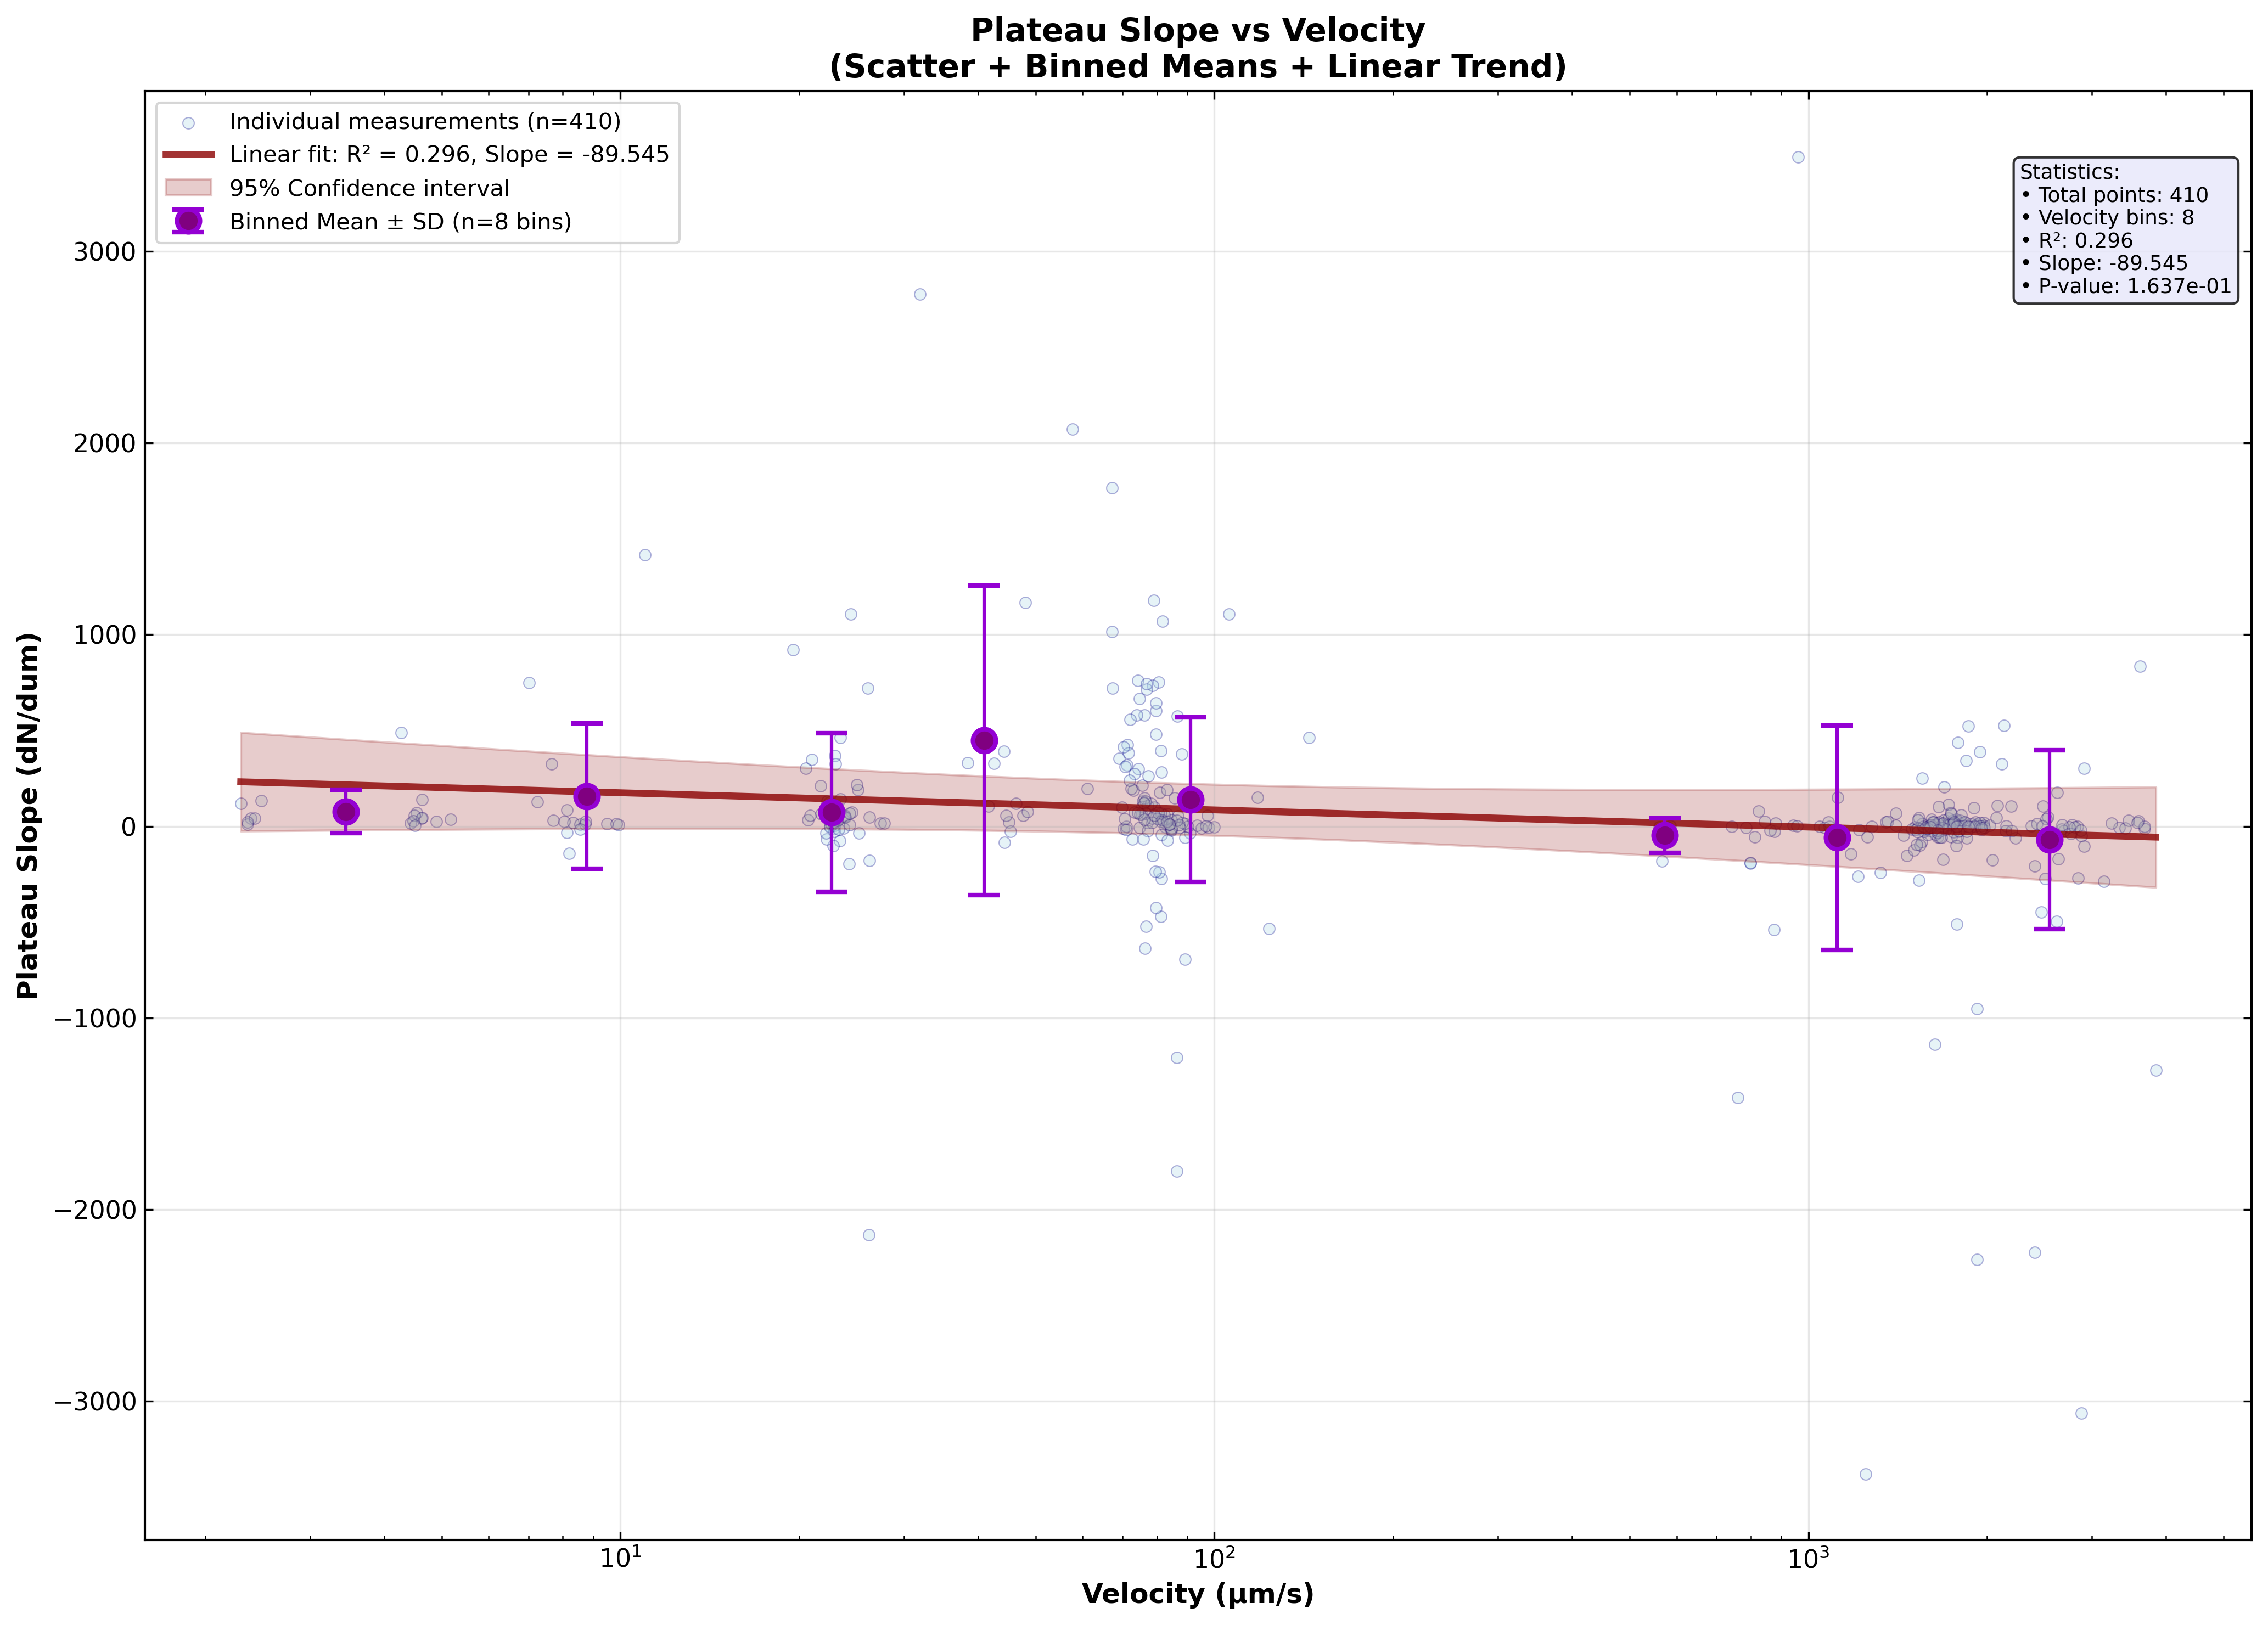

Slope analysis: 410 points, 8 bins


In [156]:
# 1. Plateau Slope vs Velocity (Combined Analysis with Binned Means)
import warnings
import scipy.stats as stats
from scipy import stats as scipy_stats
warnings.filterwarnings('ignore', category=RuntimeWarning)

# # Filter and prepare slope data
# velocity_meta_clean = np.array(selected_velocity_calc)
# slope_clean = np.array(selected_slope) * 1e6  # Convert to dN/dµm

# # Basic data filtering
valid_mask = (
    # ~np.isnan(velocity_meta_clean) & 
    # ~np.isnan(slope_clean) &
    # (velocity_meta_clean > 1e-6)
    # (slope_clean != 0) &
    # (slope_clean < 1e-6 ) &
    (slope_filtered_clean > -4000) 
)

# velocity_filtered = velocity_meta_clean[valid_mask]
# slope_filtered = slope_clean[valid_mask]
# slope_log = slope_filtered  

# # Remove infinite values
# finite_mask = np.isfinite(slope_log)
# velocity_filtered = velocity_filtered[finite_mask]
# slope_log = slope_log[finite_mask]

# Create DataFrame
slope_df = pd.DataFrame({
    'velocity': velocity_calc_clean[valid_mask],
    'slope_log': slope_filtered_clean[valid_mask],
})

# Create main plot
fig, ax = plt.subplots(figsize=(14, 10), dpi=300)

# 1. Scatter plot of all data points
ax.scatter(slope_df['velocity'], slope_df['slope_log'], 
          alpha=0.3, s=25, color='lightblue', edgecolors='darkblue', linewidth=0.5,
          label=f'Individual measurements (n={len(slope_df)})')

# 2. Create velocity bins and calculate means
num_bins = 9
velocity_min, velocity_max = slope_df['velocity'].min(), slope_df['velocity'].max()
bin_edges = np.logspace(np.log10(velocity_min), np.log10(velocity_max), num_bins + 1)

# Assign bins and calculate means
slope_df['bin_idx'] = np.digitize(slope_df['velocity'], bin_edges) - 1
slope_df['bin_idx'] = np.clip(slope_df['bin_idx'], 0, num_bins - 1)

means_df = slope_df.groupby('bin_idx').agg(
    velocity_center=('velocity', lambda x: np.sqrt(x.min() * x.max())),
    slope_mean=('slope_log', 'mean'),
    slope_std=('slope_log', 'std'),
    count=('slope_log', 'count')
).reset_index()

# Filter bins with enough data
means_df = means_df[means_df['count'] >= 3]

# 3. Plot means with error bars
if len(means_df) > 0:
    ax.errorbar(means_df['velocity_center'], means_df['slope_mean'], 
               yerr=means_df['slope_std'], 
               fmt='o', color='purple', markersize=10, markeredgecolor='darkviolet', 
               markeredgewidth=2, ecolor='darkviolet', capsize=7, capthick=2,
               label=f'Binned Mean ± SD (n={len(means_df)} bins)', zorder=5)
    
# # --- SHOW BIN LIMITS ---
# for edge in bin_edges:
#     ax.axvline(edge, color='grey', linestyle='--', alpha=0.5, zorder=0)
#     # Optionally annotate the bin edge value
#     ax.text(edge, ax.get_ylim()[1], f"{edge:.1f}", rotation=90, va='bottom', ha='right', fontsize=8, color='grey')


# 4. Fit linear trend to means
if len(means_df) >= 3:
    x_log = np.log10(means_df['velocity_center'])
    y_log = means_df['slope_mean']
    
    slope_coeff, intercept, r_value, p_value, std_err = stats.linregress(x_log, y_log)
    
    # Generate and plot trend line
    x_trend = np.logspace(np.log10(velocity_min), np.log10(velocity_max), 100)
    y_trend = intercept + slope_coeff * np.log10(x_trend)
    
    ax.plot(x_trend, y_trend, 'darkred', linewidth=3, alpha=0.8,
           label=f'Linear fit: R² = {r_value**2:.3f}, Slope = {slope_coeff:.3f}')
    
    # Add confidence interval
    n = len(means_df)
    t_val = scipy_stats.t.ppf(0.975, n-2)
    residuals = y_log - (intercept + slope_coeff * x_log)
    mse = np.sum(residuals**2) / (n-2)
    
    x_log_trend = np.log10(x_trend)
    se_trend = np.sqrt(mse * (1/n + (x_log_trend - np.mean(x_log))**2 / 
                             np.sum((x_log - np.mean(x_log))**2)))
    
    ci_lower = y_trend - t_val * se_trend
    ci_upper = y_trend + t_val * se_trend
    
    ax.fill_between(x_trend, ci_lower, ci_upper, alpha=0.2, color='darkred',
                   label='95% Confidence interval')
else:
    slope_coeff, r_value, p_value = np.nan, np.nan, np.nan

# Formatting
ax.set_xlabel("Velocity (µm/s)", fontsize=12, fontweight='bold')
ax.set_ylabel("Plateau Slope (dN/dum)", fontsize=12, fontweight='bold')
ax.set_title("Plateau Slope vs Velocity\n(Scatter + Binned Means + Linear Trend)", 
            fontsize=14, fontweight='bold')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Statistics text
if not np.isnan(r_value):
    stats_text = f"""Statistics:
• Total points: {len(slope_df)}
• Velocity bins: {len(means_df)}
• R²: {r_value**2:.3f}
• Slope: {slope_coeff:.3f}
• P-value: {p_value:.3e}"""
else:
    stats_text = f"""Statistics:
• Total points: {len(slope_df)}
• Insufficient data for trend"""

ax.text(0.89, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"Slope analysis: {len(slope_df)} points, {len(means_df)} bins")

Data velocity range: 2.3 - 3845.2 µm/s
Using bin edges: [   1    2    3    6   10   50  100 1000 3000]


<Figure size 4200x3000 with 0 Axes>

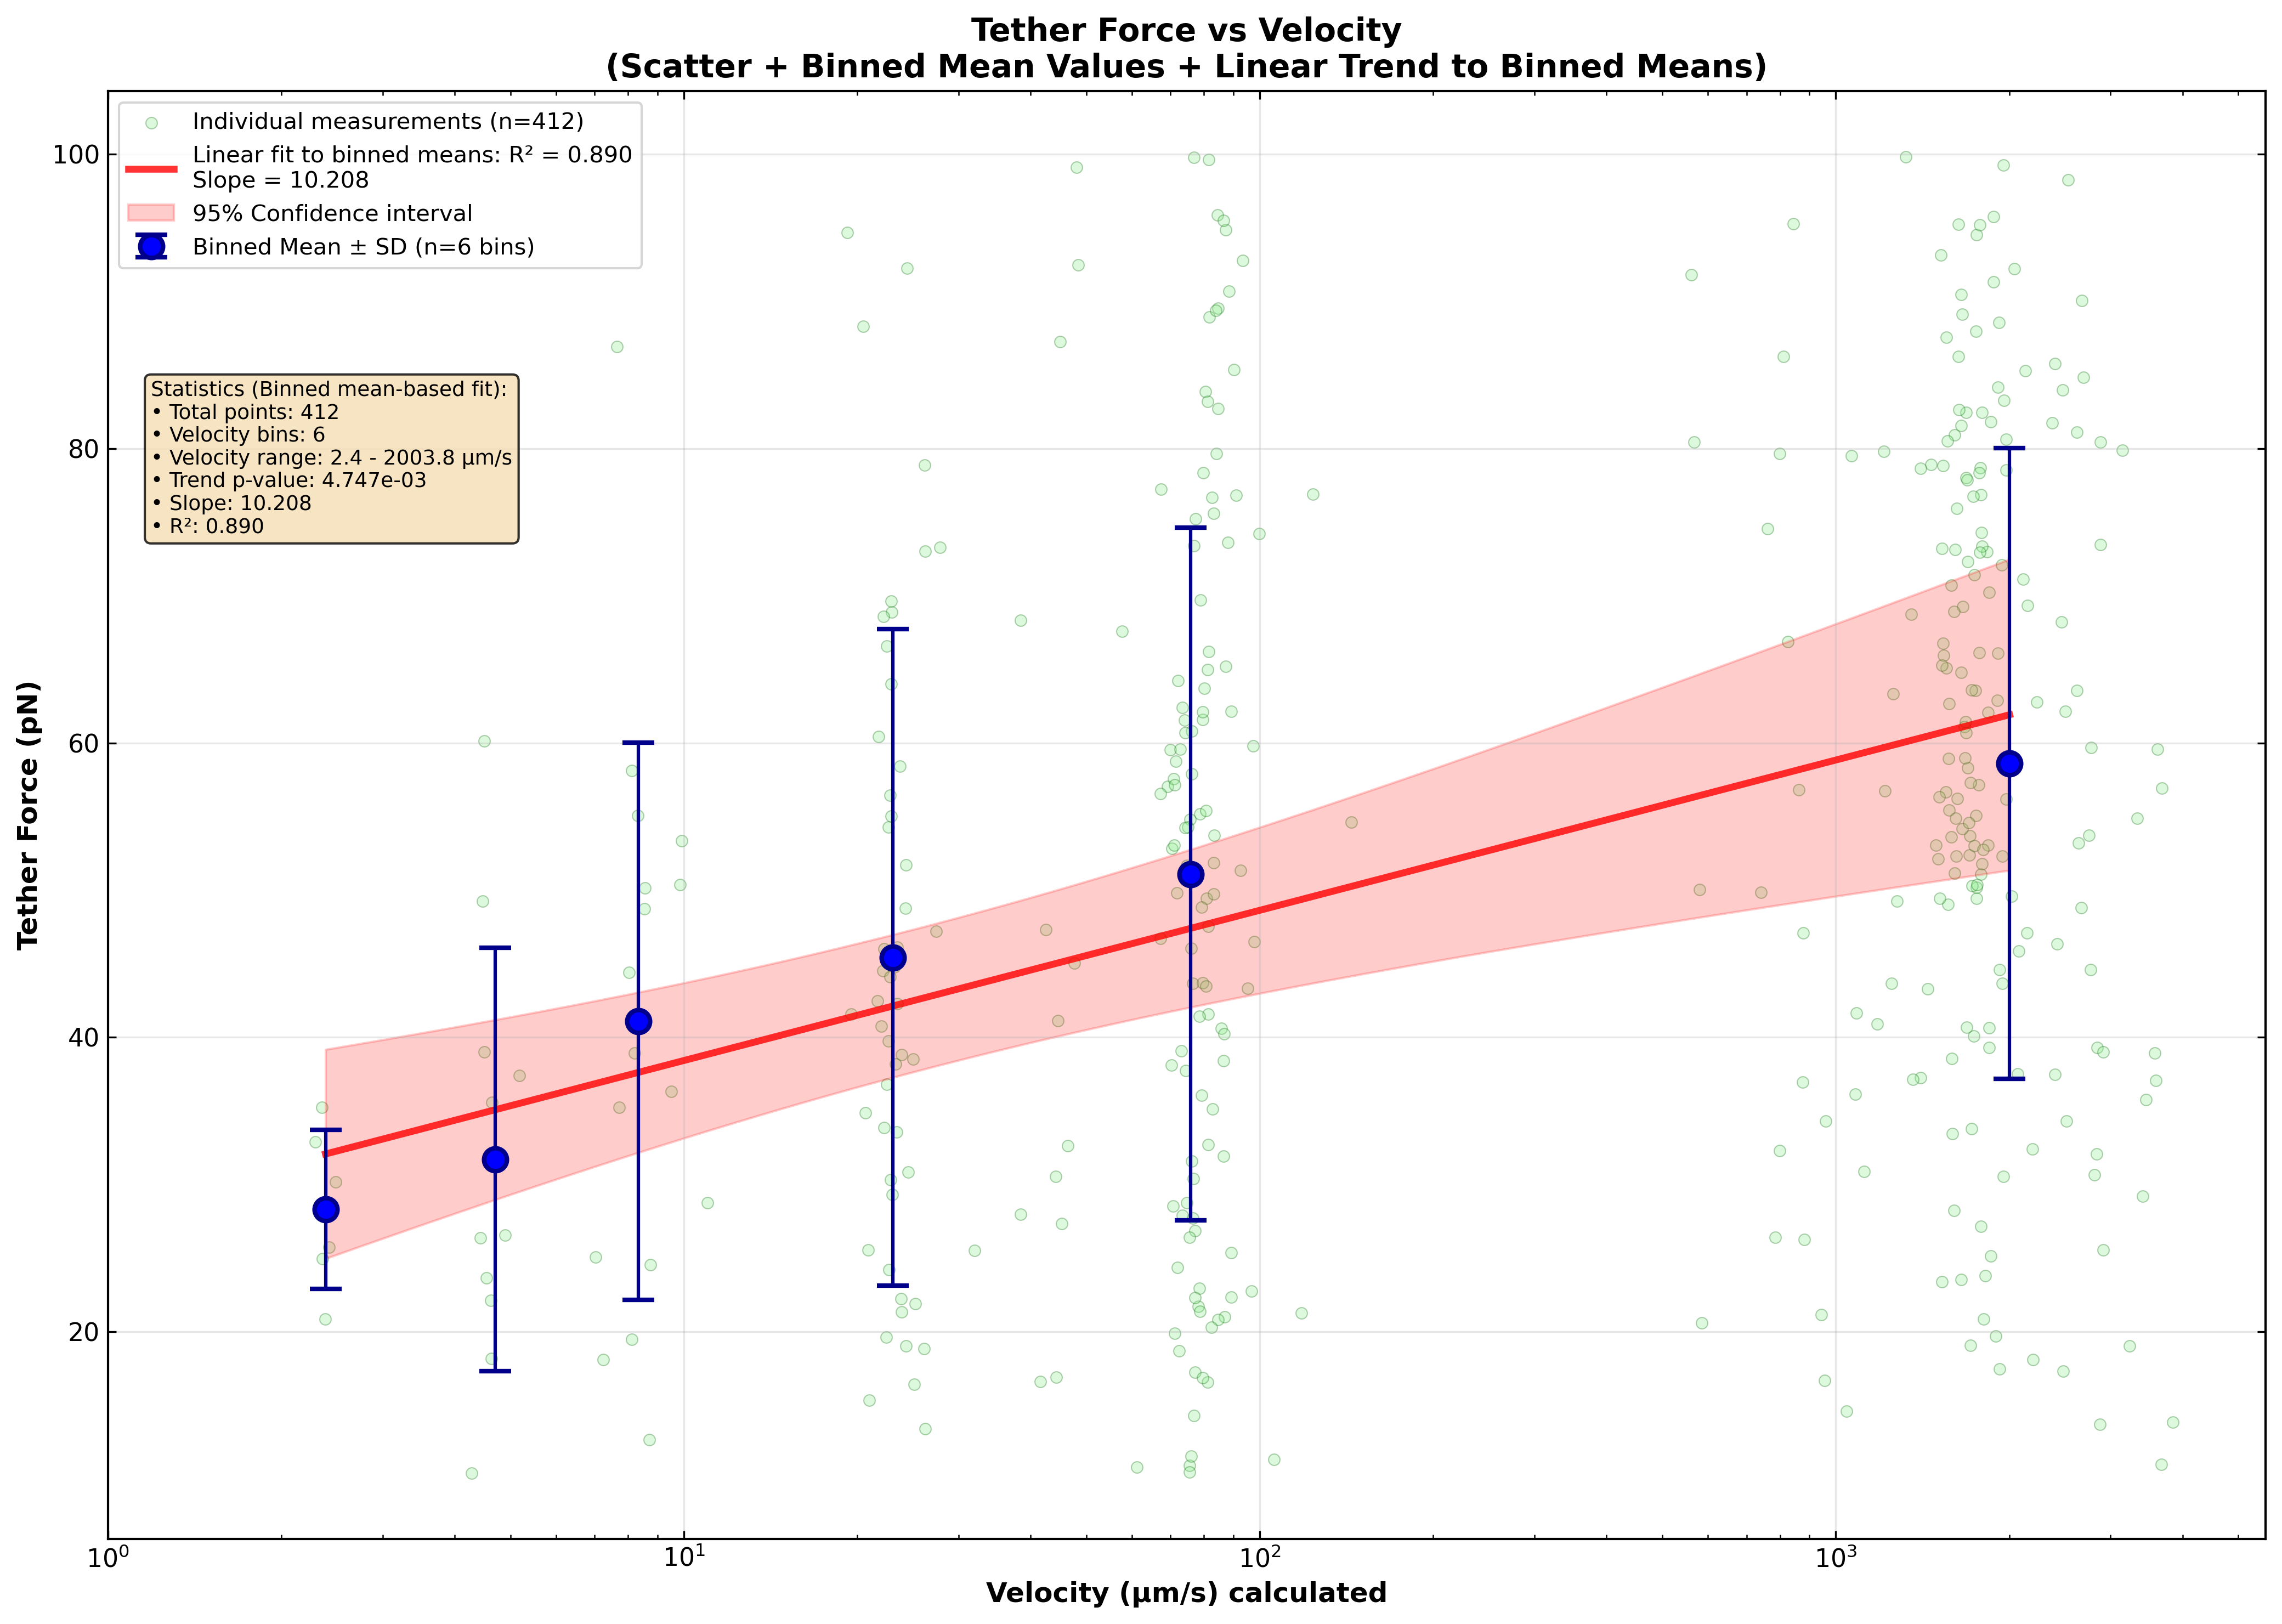

Force analysis complete:
  - Individual data points: 412
  - Velocity bins used for trend: 6
  - Linear correlation (binned means): R² = 0.890
  - Slope coefficient: 10.208
  - P-value: 4.747e-03
  - Bin information:
    Bin 1: 2.0-3.0 µm/s (6 points), center=2.4 µm/s, count=6 points
    Bin 2: 3.0-6.0 µm/s (11 points), center=4.7 µm/s, count=11 points
    Bin 3: 6.0-10.0 µm/s (16 points), center=8.3 µm/s, count=16 points
    Bin 4: 10.0-50.0 µm/s (65 points), center=23.1 µm/s, count=65 points
    Bin 5: 50.0-100.0 µm/s (111 points), center=75.9 µm/s, count=111 points
    Bin 7: 1000.0-3000.0 µm/s (180 points), center=2003.8 µm/s, count=180 points


In [157]:
# 2. Tether Force vs Velocity (Scatter + Linear Trend)
import scipy.stats as stats
from scipy.optimize import curve_fit

plt.figure(figsize=(14, 10), dpi=300)


# Main plot
fig, ax = plt.subplots(figsize=(14, 10), dpi=300)

# 1. Scatter plot of all data points 
ax.scatter(force_df['velocity_calc'], force_df['force_clean'], 
          alpha=0.3, s=25, color='lightgreen', edgecolors='darkgreen', linewidth=0.5,
          label=f'Individual measurements (n={len(force_df)})')

# 2. Create velocity bins and calculate means and standard deviations
# Define velocity bin edges (log-spaced for better distribution)
velocity_min = force_df['velocity_calc'].min()
velocity_max = force_df['velocity_calc'].max()
# First, check your actual data range
print(f"Data velocity range: {force_df['velocity_calc'].min():.1f} - {force_df['velocity_calc'].max():.1f} µm/s")

# Define your custom velocity bin edges (µm/s)
velocity_bin_edges = np.array([1,2, 3, 6, 10, 50, 100, 1000, 3000]) # Remove 3000, 6000

# OR better: Set the upper bound based on your max velocity
max_velocity = force_df['velocity_calc'].max()
print(f"Using bin edges: {velocity_bin_edges}")

# Assign each point to a velocity bin
force_df['velocity_bin_idx'] = np.digitize(force_df['velocity_calc'], velocity_bin_edges) - 1
force_df['velocity_bin_idx'] = np.clip(force_df['velocity_bin_idx'], 0, len(velocity_bin_edges) - 2)

# Create bin labels for display
velocity_bin_labels = []
for i in range(len(velocity_bin_edges) - 1):
    label = f"{velocity_bin_edges[i]:.1f}-{velocity_bin_edges[i+1]:.1f} µm/s"
    velocity_bin_labels.append(label)

# Add bin labels to dataframe
force_df['velocity_bin_label'] = [velocity_bin_labels[idx] for idx in force_df['velocity_bin_idx']]
# Calculate binned means and standard deviations
means_df_2 = force_df.groupby('velocity_bin_idx').agg(
    velocity_mean=('velocity_calc', 'mean'),
    velocity_bin_center=('velocity_calc', lambda x: np.sqrt(x.min() * x.max())),  # Geometric mean for log scale
    force_mean=('force_clean', 'mean'),
    force_std=('force_clean', 'std'),
    force_count=('force_clean', 'count'),
    bin_label=('velocity_bin_label', 'first'),
    lifetime_m_clean_mean=('lifetime_m_clean', 'mean'),
    lifetime_m_clean_std=('lifetime_m_clean', 'std'),
    lifetime_m_clean_count=('lifetime_m_clean', 'count'),
    lifetime_s_clean_mean=('lifetime_s_clean', 'mean'),
    lifetime_s_clean_std=('lifetime_s_clean', 'std'),
    lifetime_s_clean_count=('lifetime_s_clean', 'count'),
).reset_index()


# Filter out bins with too few points
means_df_2 = means_df_2[means_df_2['force_count'] != 23]


# 3. Plot means with error bars (standard deviation) using bin centers
ax.errorbar(means_df_2['velocity_bin_center'], means_df_2['force_mean'], 
           yerr=means_df_2['force_std'], 
           fmt='o', color='blue', markersize=10, markeredgecolor='darkblue', 
           markeredgewidth=2, ecolor='darkblue', capsize=7, capthick=2,
           label=f'Binned Mean ± SD (n={len(means_df_2)} bins)', zorder=5)

# 4. Fit linear trend to binned means only
if len(means_df_2) > 3:
    # Linear regression in log-log space on binned means
    vel_log_means = np.log10(means_df_2['velocity_bin_center'])
    force_clean_means = means_df_2['force_mean']
    
    slope_coeff, intercept, r_value, p_value, std_err = stats.linregress(
        vel_log_means, force_clean_means)
    
    # Generate trend line
    vel_min = max(means_df_2['velocity_bin_center'].min(), 1)
    vel_max = means_df_2['velocity_bin_center'].max()
    vel_trend = np.logspace(np.log10(vel_min), np.log10(vel_max), 100)
    force_trend = intercept + slope_coeff * np.log10(vel_trend)
    
    ax.plot(vel_trend, force_trend, 'r-', linewidth=3, alpha=0.8,
           label=f'Linear fit to binned means: R² = {r_value**2:.3f}\nSlope = {slope_coeff:.3f}')
    
    # Add confidence interval for binned means fit
    from scipy import stats as scipy_stats
    n = len(means_df_2)
    t_val = scipy_stats.t.ppf(0.975, n-2)  # 95% confidence
    
    residuals = force_clean_means - (intercept + slope_coeff * vel_log_means)
    mse = np.sum(residuals**2) / (n-2)
    
    vel_log_trend = np.log10(vel_trend)
    se_trend = np.sqrt(mse * (1/n + (vel_log_trend - np.mean(vel_log_means))**2 / 
                             np.sum((vel_log_means - np.mean(vel_log_means))**2)))
    
    ci_lower = force_trend - t_val * se_trend
    ci_upper = force_trend + t_val * se_trend
    
    ax.fill_between(vel_trend, ci_lower, ci_upper, alpha=0.2, color='red',
                   label='95% Confidence interval')

# Formatting
ax.set_xlabel("Velocity (µm/s) calculated", fontsize=12, fontweight='bold')
ax.set_ylabel("Tether Force (pN)", fontsize=12, fontweight='bold')
ax.set_title("Tether Force vs Velocity\n(Scatter + Binned Mean Values + Linear Trend to Binned Means)", 
            fontsize=14, fontweight='bold')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Add statistics text
stats_text = f"""Statistics (Binned mean-based fit):
• Total points: {len(force_df)}
• Velocity bins: {len(means_df_2)}
• Velocity range: {means_df_2['velocity_bin_center'].min():.1f} - {means_df_2['velocity_bin_center'].max():.1f} µm/s
• Trend p-value: {p_value:.3e}
• Slope: {slope_coeff:.3f}
• R²: {r_value**2:.3f}"""

ax.text(0.02, 0.8, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.xlim(left = 10e-1)
plt.show()

print(f"Force analysis complete:")
print(f"  - Individual data points: {len(force_df)}")
print(f"  - Velocity bins used for trend: {len(means_df_2)}")
print(f"  - Linear correlation (binned means): R² = {r_value**2:.3f}")
print(f"  - Slope coefficient: {slope_coeff:.3f}")
print(f"  - P-value: {p_value:.3e}")
print(f"  - Bin information:")
for i, row in means_df_2.iterrows():
    print(f"    Bin {i+1}: {row['bin_label']} ({row['force_count']} points), center={row['velocity_bin_center']:.1f} µm/s, count={row['force_count']} points")
    # print(f"    Bin {i}: center={row['velocity_bin_center']:.1f} µm/s, count={row['force_count']} points")

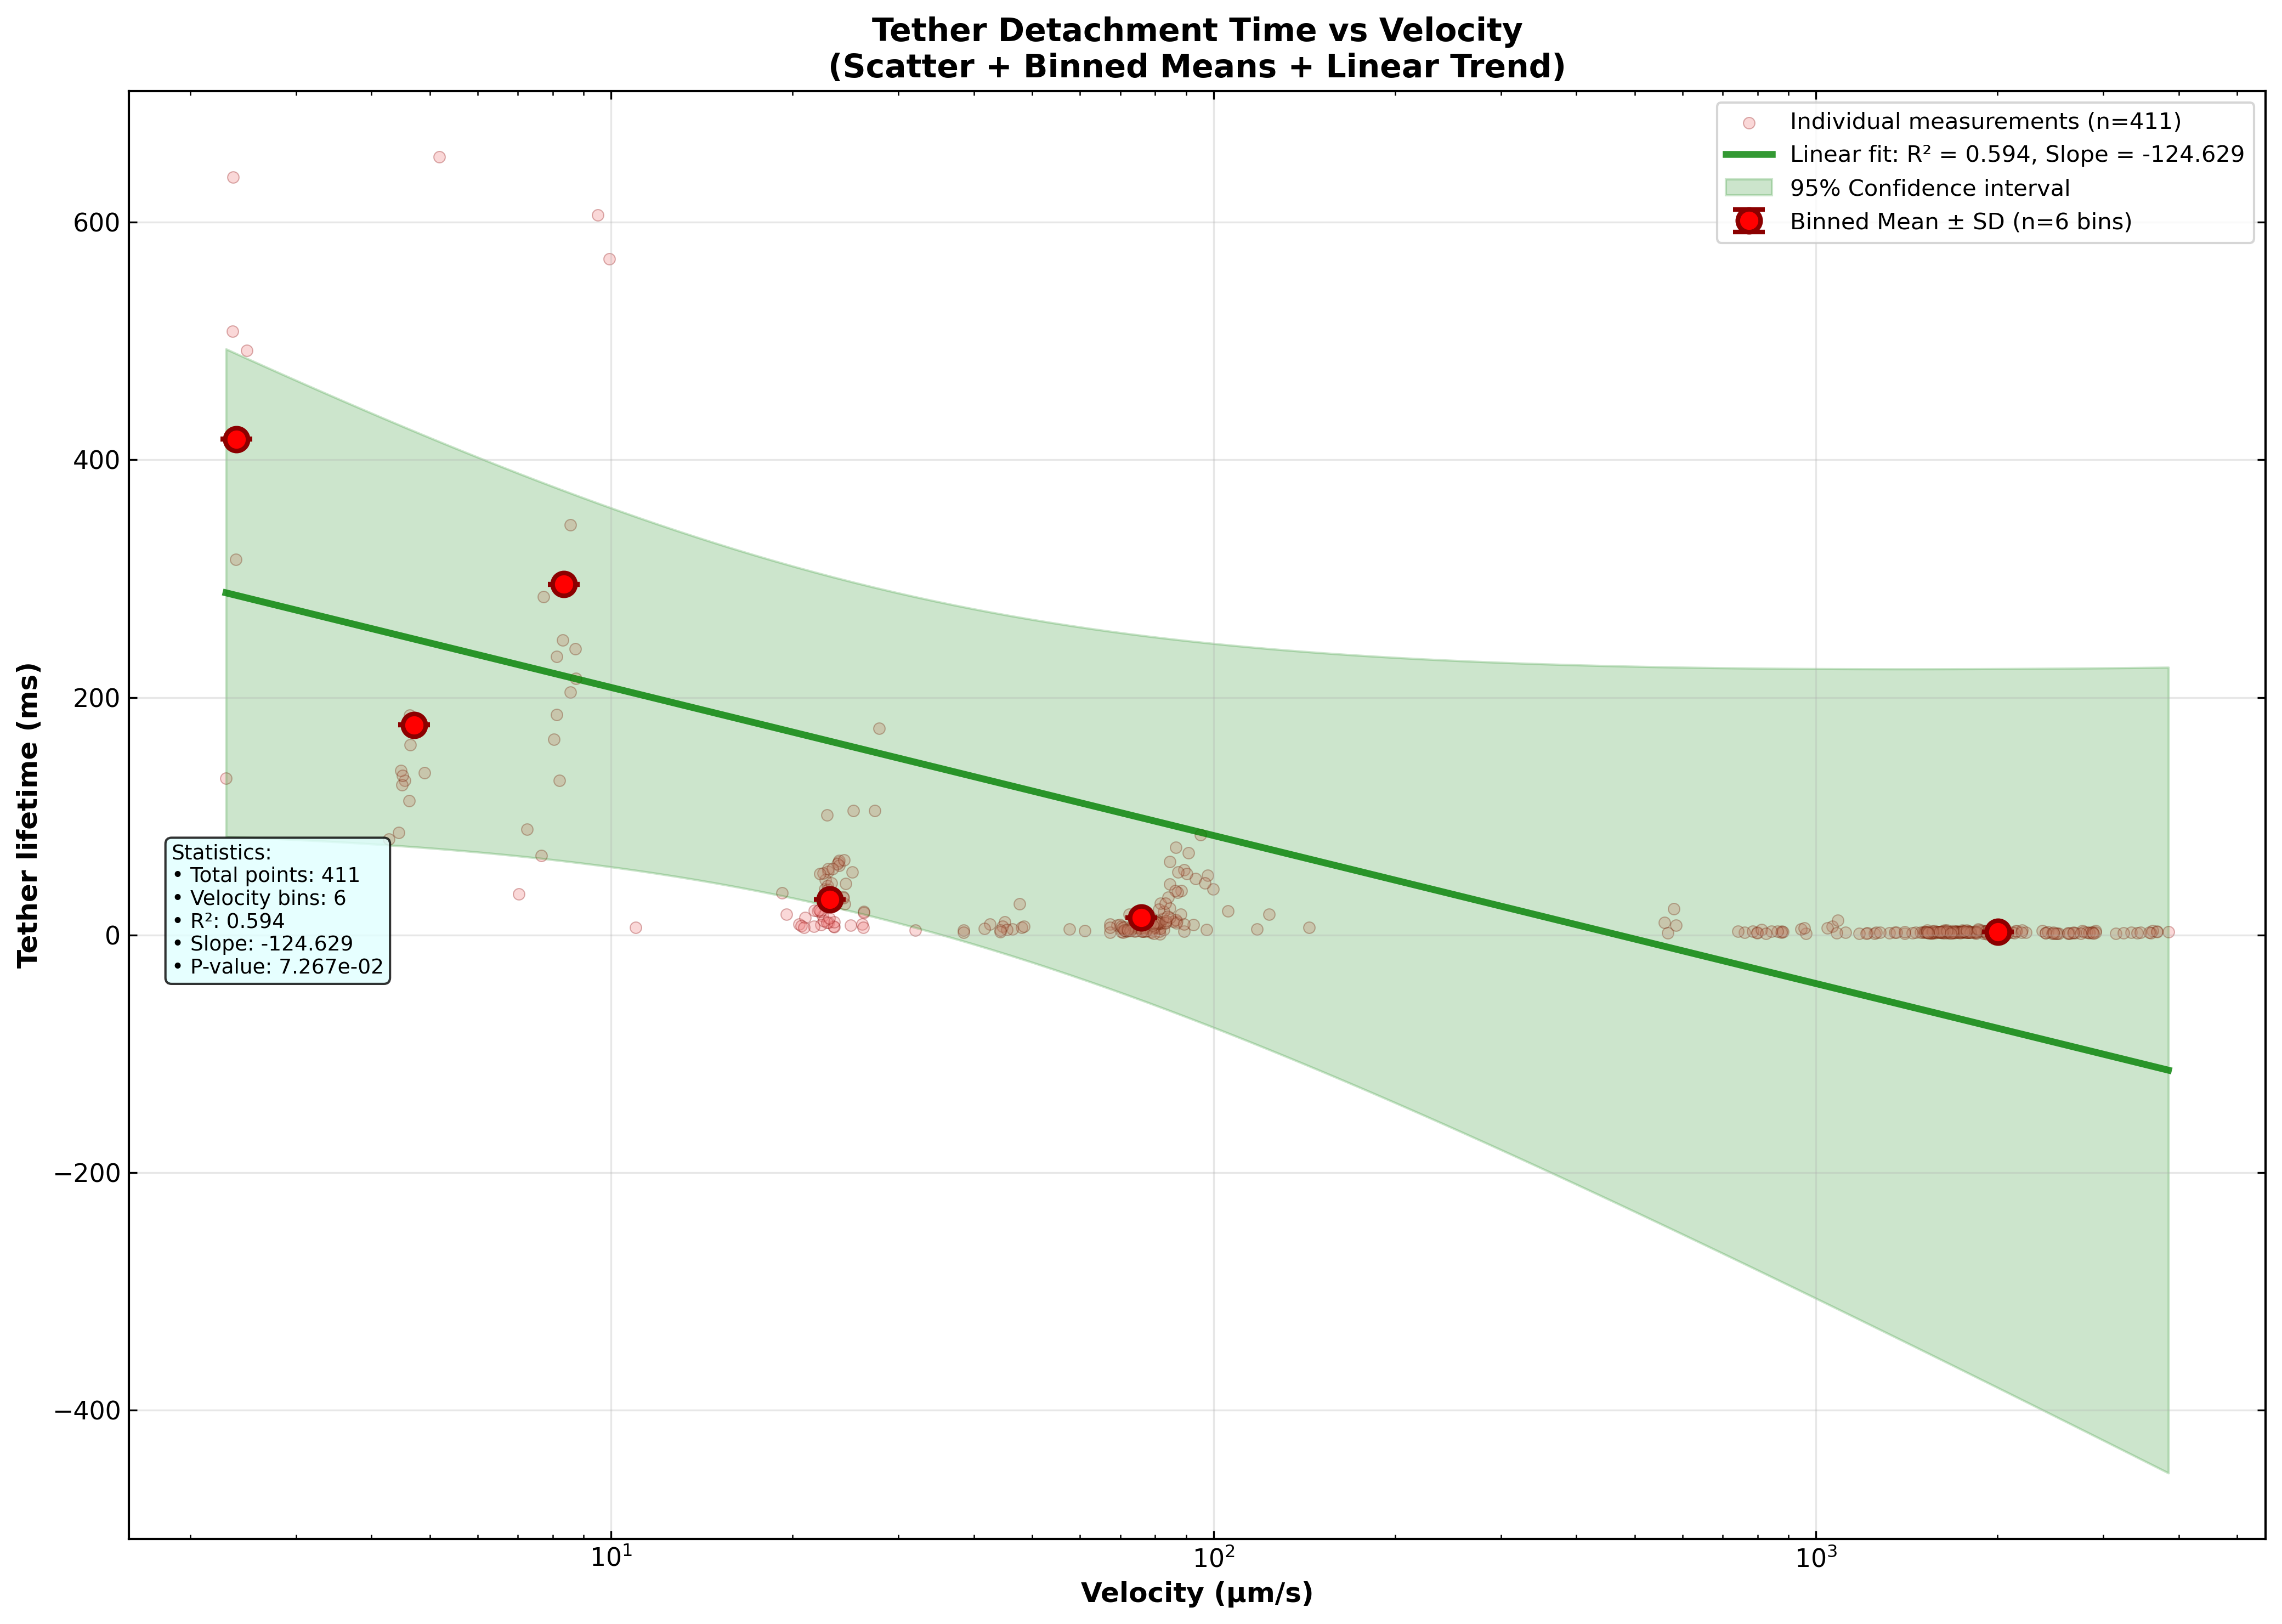

Time analysis: 411 points, 6 bins


In [158]:
# 3. Detachment Time vs Velocity (Combined Analysis with Binned Means)
import warnings
import scipy.stats as stats
from scipy import stats as scipy_stats
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Create main plot
fig, ax = plt.subplots(figsize=(14, 10), dpi=300)


means_df_3 = means_df_2.copy()

# convert liftime_s to lifetime_ms
force_df['lifetime_ms_clean'] = force_df['lifetime_s_clean'] * 1e3
means_df_3['lifetime_ms_clean_mean'] = means_df_3['lifetime_s_clean_mean'] * 1e3
means_df_3['lifetime_ms_clean_std']  = means_df_3['lifetime_s_clean_std'] * 1e3

# # Filter bins with enough data
force_df = force_df[force_df['lifetime_ms_clean'] < 1000] #filter out tethers that take more than 1 second

# 1. Scatter plot of all data points
ax.scatter(force_df['velocity_calc'], force_df['lifetime_ms_clean'], 
          alpha=0.3, s=25, color='lightcoral', edgecolors='darkred', linewidth=0.5,
          label=f'Individual measurements (n={len(force_df)})')


# 3. Plot means with error bars
if len(means_df_3) > 0:
    ax.errorbar(means_df_3['velocity_bin_center'], means_df_3['lifetime_ms_clean_mean'], 
               yerr=means_df_3['lifetime_s_clean_std'], 
               fmt='o', color='red', markersize=10, markeredgecolor='darkred', 
               markeredgewidth=2, ecolor='darkred', capsize=7, capthick=2,
               label=f'Binned Mean ± SD (n={len(means_df_3)} bins)', zorder=5)

# 4. Fit linear trend to means

x_log = np.log10(means_df_3['velocity_bin_center'])
y_log = means_df_3['lifetime_ms_clean_mean']


slope_coeff, intercept, r_value, p_value, std_err = stats.linregress(x_log, y_log)

# Generate and plot trend line
# x_trend = (np.log10(vel_min), np.log10(vel_max), 100)
x_trend = np.logspace(np.log10(velocity_min), np.log10(velocity_max), 100)
y_trend = intercept + slope_coeff * np.log10(x_trend)

ax.plot(x_trend, y_trend, 'green', linewidth=3, alpha=0.8,
        label=f'Linear fit: R² = {r_value**2:.3f}, Slope = {slope_coeff:.3f}')

# Add confidence interval
n = len(means_df_3)
t_val = scipy_stats.t.ppf(0.975, n-2)
residuals = y_log - (intercept + slope_coeff * x_log)
mse = np.sum(residuals**2) / (n-2)

x_log_trend = np.log10(x_trend)
se_trend = np.sqrt(mse * (1/n + (x_log_trend - np.mean(x_log))**2 / 
                            np.sum((x_log - np.mean(x_log))**2)))

ci_lower = y_trend - t_val * se_trend
ci_upper = y_trend + t_val * se_trend

ax.fill_between(x_trend, ci_lower, ci_upper, alpha=0.2, color='green',
                label='95% Confidence interval')


# Formatting
ax.set_xlabel("Velocity (µm/s)", fontsize=12, fontweight='bold')
ax.set_ylabel("Tether lifetime (ms)", fontsize=12, fontweight='bold')
ax.set_title("Tether Detachment Time vs Velocity\n(Scatter + Binned Means + Linear Trend)", 
            fontsize=14, fontweight='bold')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Statistics text
if not np.isnan(r_value):
    stats_text = f"""Statistics:
• Total points: {len(force_df)}
• Velocity bins: {len(means_df_3)}
• R²: {r_value**2:.3f}
• Slope: {slope_coeff:.3f}
• P-value: {p_value:.3e}"""
else:
    stats_text = f"""Statistics:
• Total points: {len(force_df)}
• Insufficient data for trend"""

ax.text(0.02, 0.48, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"Time analysis: {len(force_df)} points, {len(means_df_3)} bins")

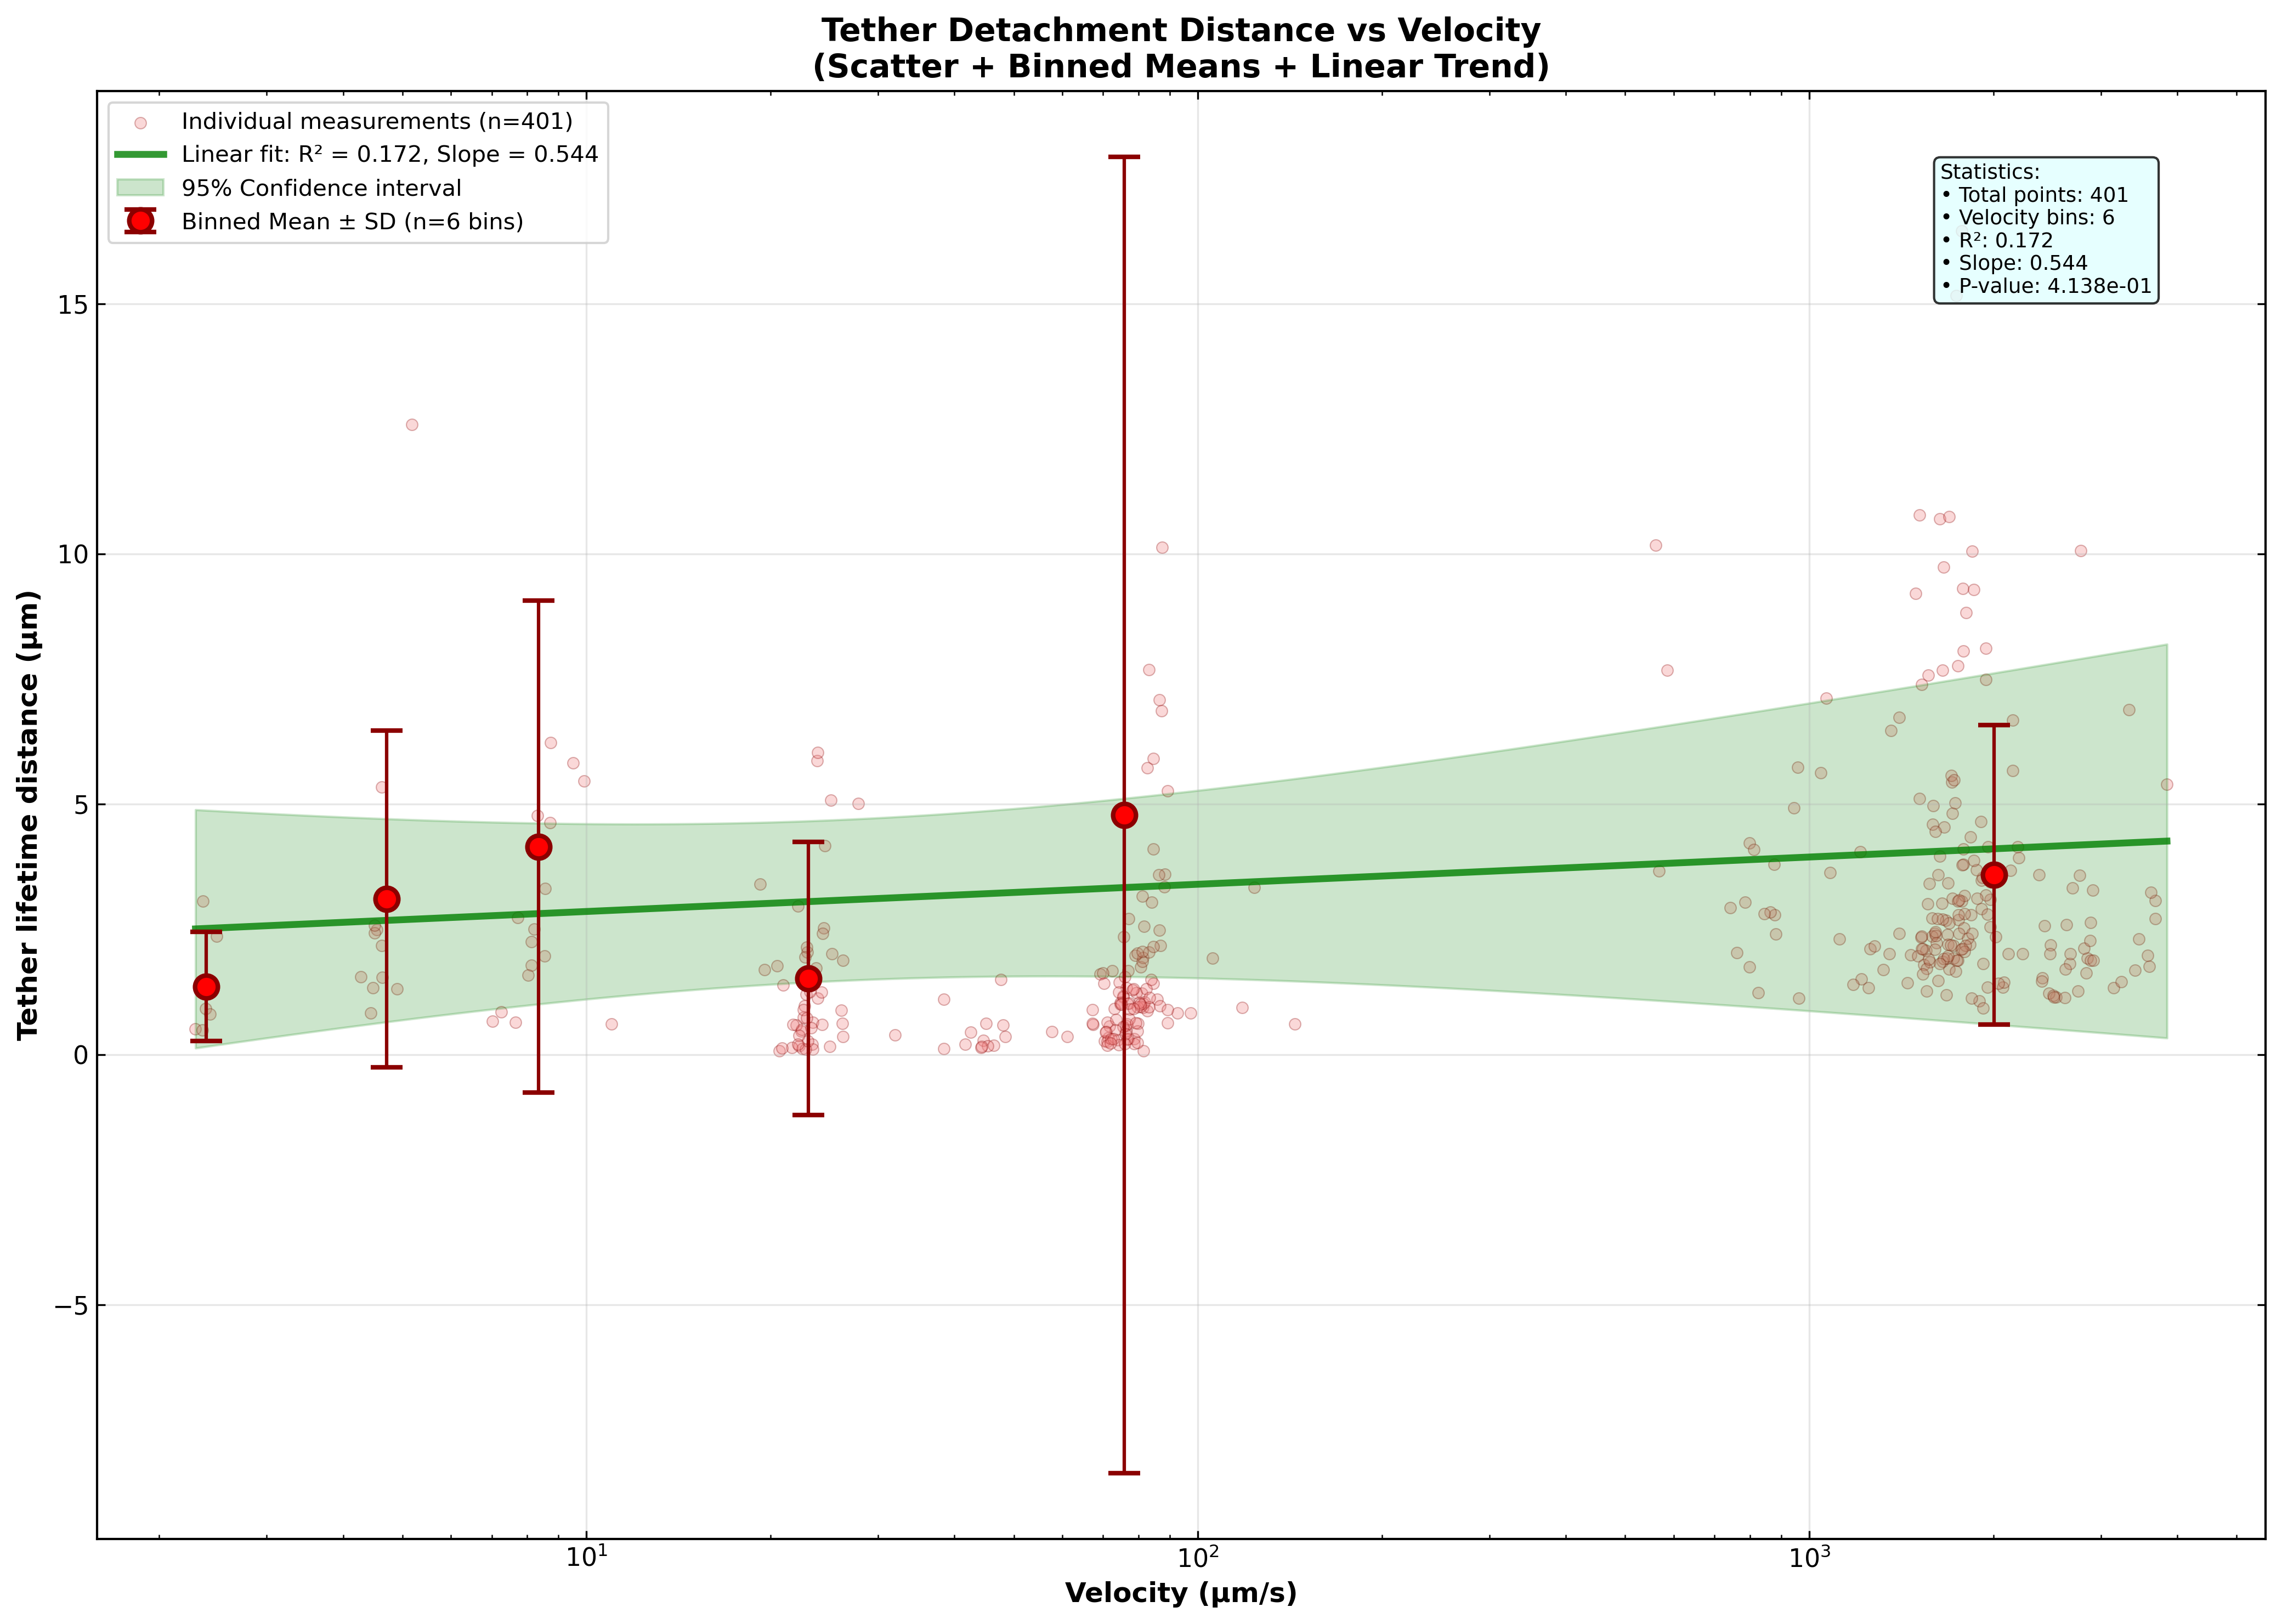

Time analysis: 401 points, 6 bins


In [159]:
# 3. Detachment Time vs Velocity (Combined Analysis with Binned Means)
import warnings
import scipy.stats as stats
from scipy import stats as scipy_stats
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Create main plot
fig, ax = plt.subplots(figsize=(14, 10), dpi=300)


means_df_4 = means_df_3.copy()
scale_um = 1e6

# convert liftime_s to lifetime_m
force_df['lifetime_mm_clean'] = force_df['lifetime_m_clean'] 
means_df_3['lifetime_mm_clean_mean'] = means_df_3['lifetime_m_clean_mean'] 
means_df_3['lifetime_m_clean_std']  = means_df_3['lifetime_m_clean_std'] 

# # Filter bins with enough data
force_df = force_df[force_df['lifetime_mm_clean']* scale_um < 20]

# 1. Scatter plot of all data points
ax.scatter(force_df['velocity_calc'], force_df['lifetime_mm_clean'] * scale_um, 
          alpha=0.3, s=25, color='lightcoral', edgecolors='darkred', linewidth=0.5,
          label=f'Individual measurements (n={len(force_df)})')


# 3. Plot means with error bars
if len(means_df_3) > 0:
    ax.errorbar(means_df_3['velocity_bin_center'], means_df_3['lifetime_mm_clean_mean']* scale_um, 
               yerr=means_df_3['lifetime_m_clean_std']* scale_um, 
               fmt='o', color='red', markersize=10, markeredgecolor='darkred', 
               markeredgewidth=2, ecolor='darkred', capsize=7, capthick=2,
               label=f'Binned Mean ± SD (n={len(means_df_3)} bins)', zorder=5)

# 4. Fit linear trend to means

x_log = np.log10(means_df_3['velocity_bin_center'])
y_log = means_df_3['lifetime_mm_clean_mean']* scale_um


slope_coeff, intercept, r_value, p_value, std_err = stats.linregress(x_log, y_log)

# Generate and plot trend line
# x_trend = (np.log10(vel_min), np.log10(vel_max), 100)
x_trend = np.logspace(np.log10(velocity_min), np.log10(velocity_max), 100)
y_trend = intercept + slope_coeff * np.log10(x_trend)

ax.plot(x_trend, y_trend, 'green', linewidth=3, alpha=0.8,
        label=f'Linear fit: R² = {r_value**2:.3f}, Slope = {slope_coeff:.3f}')

# Add confidence interval
n = len(means_df_3)
t_val = scipy_stats.t.ppf(0.975, n-2)
residuals = y_log - (intercept + slope_coeff * x_log)
mse = np.sum(residuals**2) / (n-2)

x_log_trend = np.log10(x_trend)
se_trend = np.sqrt(mse * (1/n + (x_log_trend - np.mean(x_log))**2 / 
                            np.sum((x_log - np.mean(x_log))**2)))

ci_lower = y_trend - t_val * se_trend
ci_upper = y_trend + t_val * se_trend

ax.fill_between(x_trend, ci_lower, ci_upper, alpha=0.2, color='green',
                label='95% Confidence interval')


# Formatting
ax.set_xlabel("Velocity (µm/s)", fontsize=12, fontweight='bold')
ax.set_ylabel("Tether lifetime distance (µm)", fontsize=12, fontweight='bold')
ax.set_title("Tether Detachment Distance vs Velocity\n(Scatter + Binned Means + Linear Trend)", 
            fontsize=14, fontweight='bold')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
# ax.set_ylim(bottom=-1)

# Statistics text
if not np.isnan(r_value):
    stats_text = f"""Statistics:
• Total points: {len(force_df)}
• Velocity bins: {len(means_df_3)}
• R²: {r_value**2:.3f}
• Slope: {slope_coeff:.3f}
• P-value: {p_value:.3e}"""
else:
    stats_text = f"""Statistics:
• Total points: {len(force_df)}
• Insufficient data for trend"""

ax.text(0.85, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"Time analysis: {len(force_df)} points, {len(means_df_3)} bins")

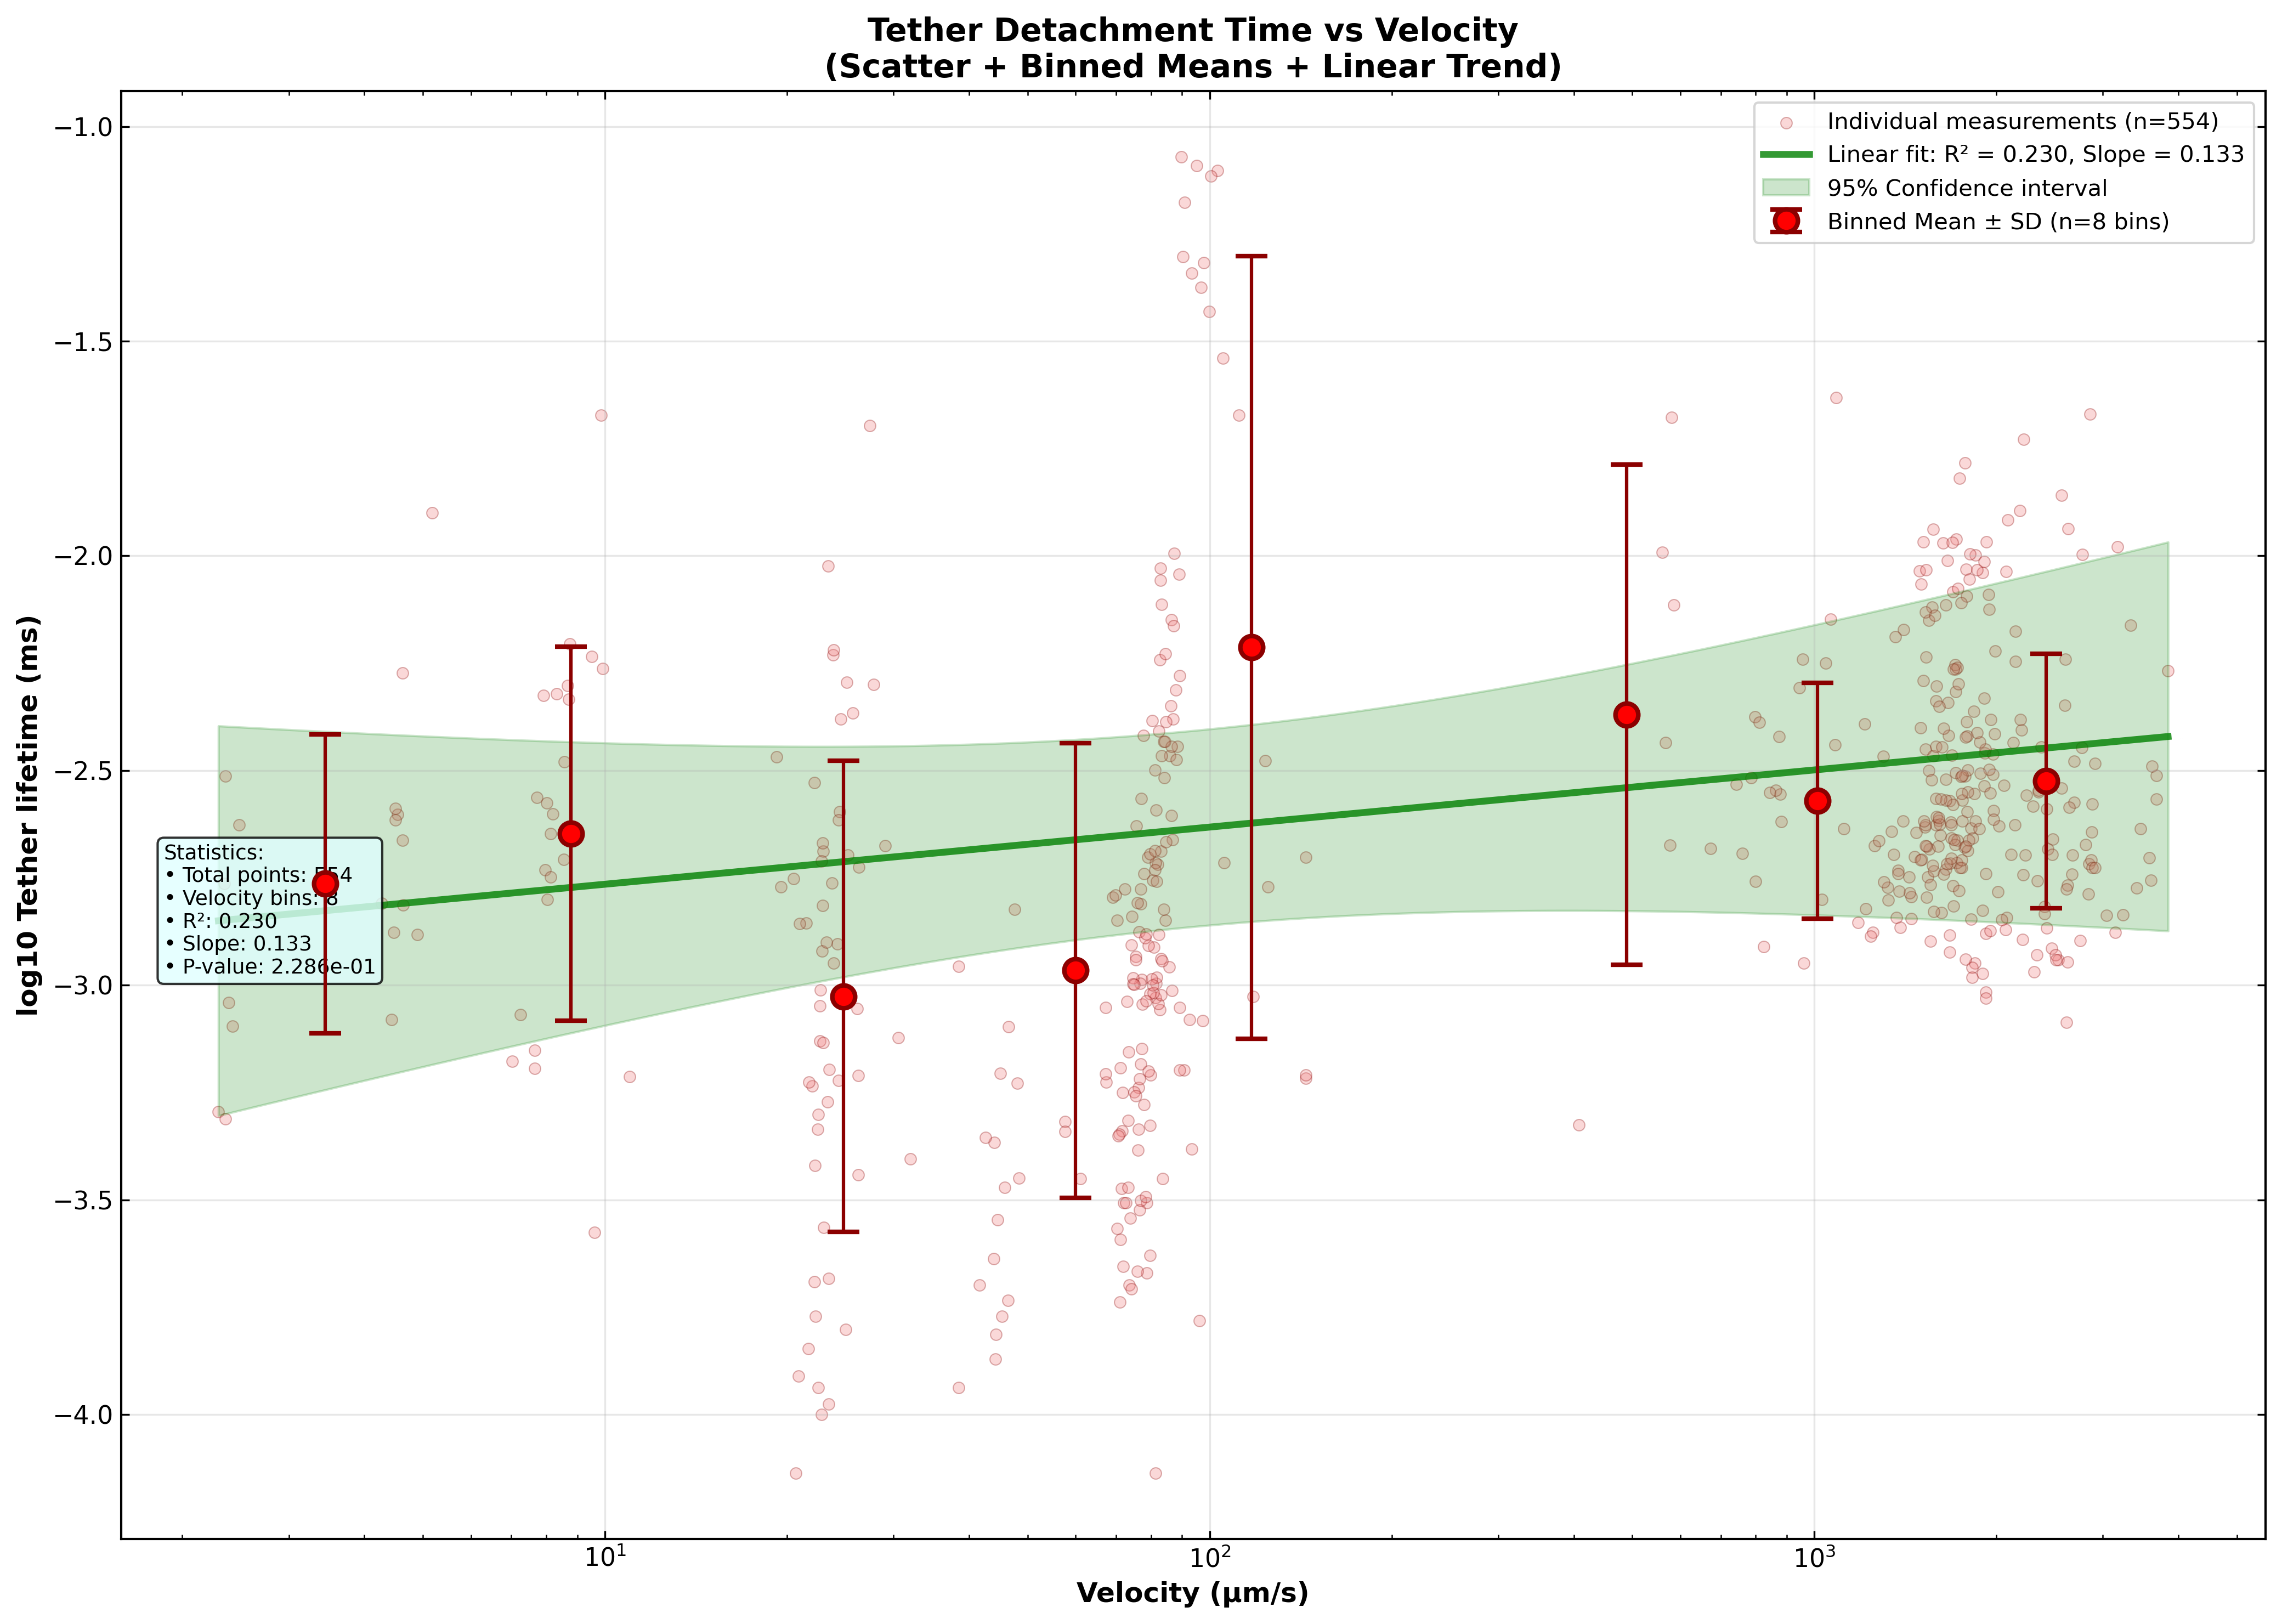

Time analysis: 554 points, 8 bins


In [160]:
# 3. Detachment Time vs Velocity (Combined Analysis with Binned Means)
import warnings
import scipy.stats as stats
from scipy import stats as scipy_stats
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Filter and prepare time data
velocity_filtered = np.array(selected_velocity_calc)
time_filtered = np.array(selected_tether_lifetime_m)

# Basic data filtering
valid_mask = (
    ~np.isnan(velocity_filtered) & 
    ~np.isnan(time_filtered) &
    (velocity_filtered > 1e-6) &
    (time_filtered > 0)
)

velocity_filtered = velocity_filtered[valid_mask]
time_filtered = time_filtered[valid_mask]
time_log = safe_log10(time_filtered * 1e3)  # Convert to ms

# Remove infinite values
finite_mask = np.isfinite(time_log)
velocity_filtered = velocity_filtered[finite_mask]
time_log = time_log[finite_mask]

# Create DataFrame
time_df = pd.DataFrame({
    'velocity': velocity_filtered,
    'time_log': time_log
})

# Create main plot
fig, ax = plt.subplots(figsize=(14, 10), dpi=300)

# 1. Scatter plot of all data points
ax.scatter(time_df['velocity'], time_df['time_log'], 
          alpha=0.3, s=25, color='lightcoral', edgecolors='darkred', linewidth=0.5,
          label=f'Individual measurements (n={len(time_df)})')

# 2. Create velocity bins and calculate means
num_bins = 8
velocity_min, velocity_max = time_df['velocity'].min(), time_df['velocity'].max()
bin_edges = np.logspace(np.log10(velocity_min), np.log10(velocity_max), num_bins + 1)

# Assign bins and calculate means
time_df['bin_idx'] = np.digitize(time_df['velocity'], bin_edges) - 1
time_df['bin_idx'] = np.clip(time_df['bin_idx'], 0, num_bins - 1)

means_df = time_df.groupby('bin_idx').agg(
    velocity_center=('velocity', lambda x: np.sqrt(x.min() * x.max())),
    time_mean=('time_log', 'mean'),
    time_std=('time_log', 'std'),
    count=('time_log', 'count')
).reset_index()

# Filter bins with enough data
means_df = means_df[means_df['count'] >= 1]

# 3. Plot means with error bars
if len(means_df) > 0:
    ax.errorbar(means_df['velocity_center'], means_df['time_mean'], 
               yerr=means_df['time_std'], 
               fmt='o', color='red', markersize=10, markeredgecolor='darkred', 
               markeredgewidth=2, ecolor='darkred', capsize=7, capthick=2,
               label=f'Binned Mean ± SD (n={len(means_df)} bins)', zorder=5)

# 4. Fit linear trend to means
if len(means_df) >= 3:
    x_log = np.log10(means_df['velocity_center'])
    y_log = means_df['time_mean']
    
    slope_coeff, intercept, r_value, p_value, std_err = stats.linregress(x_log, y_log)
    
    # Generate and plot trend line
    x_trend = np.logspace(np.log10(velocity_min), np.log10(velocity_max), 100)
    y_trend = intercept + slope_coeff * np.log10(x_trend)
    
    ax.plot(x_trend, y_trend, 'green', linewidth=3, alpha=0.8,
           label=f'Linear fit: R² = {r_value**2:.3f}, Slope = {slope_coeff:.3f}')
    
    # Add confidence interval
    n = len(means_df)
    t_val = scipy_stats.t.ppf(0.975, n-2)
    residuals = y_log - (intercept + slope_coeff * x_log)
    mse = np.sum(residuals**2) / (n-2)
    
    x_log_trend = np.log10(x_trend)
    se_trend = np.sqrt(mse * (1/n + (x_log_trend - np.mean(x_log))**2 / 
                             np.sum((x_log - np.mean(x_log))**2)))
    
    ci_lower = y_trend - t_val * se_trend
    ci_upper = y_trend + t_val * se_trend
    
    ax.fill_between(x_trend, ci_lower, ci_upper, alpha=0.2, color='green',
                   label='95% Confidence interval')
else:
    slope_coeff, r_value, p_value = np.nan, np.nan, np.nan

# Formatting
ax.set_xlabel("Velocity (µm/s)", fontsize=12, fontweight='bold')
ax.set_ylabel("log10 Tether lifetime (ms)", fontsize=12, fontweight='bold')
ax.set_title("Tether Detachment Time vs Velocity\n(Scatter + Binned Means + Linear Trend)", 
            fontsize=14, fontweight='bold')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Statistics text
if not np.isnan(r_value):
    stats_text = f"""Statistics:
• Total points: {len(time_df)}
• Velocity bins: {len(means_df)}
• R²: {r_value**2:.3f}
• Slope: {slope_coeff:.3f}
• P-value: {p_value:.3e}"""
else:
    stats_text = f"""Statistics:
• Total points: {len(time_df)}
• Insufficient data for trend"""

ax.text(0.02, 0.48, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"Time analysis: {len(time_df)} points, {len(means_df)} bins")

In [161]:
delta_avg_clean = np.array(selected_delta_avg)
selected_tether_lifetime_s_clean = np.array(selected_tether_lifetime_s)

valid_mask = (
    ~np.isnan(delta_avg_clean) &
    (delta_avg_clean != 0) &
    (np.abs(delta_avg_clean) > 10e-12) &   # >10 pN
    (np.abs(delta_avg_clean) < 100e-12)       # <1000 pN
)

force_filtered = delta_avg_clean[valid_mask]
selected_tether_lifetime_s_clean_filtered = selected_tether_lifetime_s_clean[valid_mask]
force_abs_pN = np.abs(force_filtered) * 1e12 # change to pN
selected_tether_lifetime_s_clean_filtered_ms = selected_tether_lifetime_s_clean_filtered * 1e3


# Remove infinite values
finite_mask =  np.isfinite(force_abs_pN)
force_abs_clean = force_abs_pN[finite_mask]
selected_tether_lifetime_s_clean_filtered_ms_clean = selected_tether_lifetime_s_clean_filtered_ms[finite_mask]


# Create DataFrame for analysis
force_df = pd.DataFrame({
    'velocity': velocity_clean,
    'velocity_log': velocity_log_clean,
    'force_log': force_log_clean
})

###%####
# 5. Tether lifetime vs tether extraction force (Combined Analysis with Binned Means)
plt.figure(figsize=(14, 10), dpi=300)

# Create DataFrame for analysis
force_bins_df = pd.DataFrame({
    'force_log': safe_log10(force_abs_clean),  
    'lifetime_log': safe_log10(selected_tether_lifetime_s_clean_filtered_ms_clean)
})

# Remove invalid log values
force_bins_df = force_bins_df[np.isfinite(force_bins_df['force_log']) & np.isfinite(force_bins_df['lifetime_log'])]

# Main plot
fig, ax = plt.subplots(figsize=(14, 10), dpi=300)

# 1. Scatter plot of all data points
ax.scatter(force_bins_df['force_log'], force_bins_df['lifetime_log'], 
          alpha=0.3, s=25, color='plum', edgecolors='purple', linewidth=0.5,
          label=f'Individual measurements (n={len(force_bins_df)})')

# 2. Create force bins and calculate means and standard deviations
force_min = force_bins_df['force_log'].min()
force_max = force_bins_df['force_log'].max()
num_force_bins = 5

# Create evenly spaced bin edges for force
force_bin_edges = np.linspace(force_min, force_max, num_force_bins + 1)

# Assign each point to a force bin
force_bins_df['force_bin_idx'] = np.digitize(force_bins_df['force_log'], force_bin_edges) - 1
force_bins_df['force_bin_idx'] = np.clip(force_bins_df['force_bin_idx'], 0, num_force_bins - 1)

# Calculate binned means and standard deviations
means_df_force = force_bins_df.groupby('force_bin_idx').agg(
    force_mean=('force_log', 'mean'),
    force_bin_center=('force_log', lambda x: (x.min() + x.max()) / 2),
    lifetime_mean=('lifetime_log', 'mean'),
    lifetime_std=('lifetime_log', 'std'),
    lifetime_count=('lifetime_log', 'count')
).reset_index()

# Filter out bins with too few points
means_df_force = means_df_force[means_df_force['lifetime_count'] >= 3]

# Plot means with error bars
ax.errorbar(means_df_force['force_bin_center'], means_df_force['lifetime_mean'], 
           yerr=means_df_force['lifetime_std'], 
           fmt='o', color='purple', markersize=10, markeredgecolor='darkviolet', 
           markeredgewidth=2, ecolor='darkviolet', capsize=7, capthick=2,
           label=f'Binned Mean ± SD (n={len(means_df_force)} bins)', zorder=5)

# 3. Fit linear trend to binned means
if len(means_df_force) > 3:
    force_log_means = means_df_force['force_bin_center']
    lifetime_log_means = means_df_force['lifetime_mean']
    
    slope_coeff, intercept, r_value, p_value, std_err = stats.linregress(
        force_log_means, lifetime_log_means)
    
    # Generate trend line
    force_trend = np.linspace(means_df_force['force_bin_center'].min(), 
                             means_df_force['force_bin_center'].max(), 100)
    lifetime_trend = intercept + slope_coeff * force_trend
    
    ax.plot(force_trend, lifetime_trend, 'darkred', linewidth=3, alpha=0.8,
           label=f'Linear fit to binned means: R² = {r_value**2:.3f}\nSlope = {slope_coeff:.3f}')
    
    # Add confidence interval
    n = len(means_df_force)
    t_val = scipy_stats.t.ppf(0.975, n-2)
    residuals = lifetime_log_means - (intercept + slope_coeff * force_log_means)
    mse = np.sum(residuals**2) / (n-2)
    
    se_trend = np.sqrt(mse * (1/n + (force_trend - np.mean(force_log_means))**2 / 
                             np.sum((force_log_means - np.mean(force_log_means))**2)))
    
    ci_lower = lifetime_trend - t_val * se_trend
    ci_upper = lifetime_trend + t_val * se_trend
    
    ax.fill_between(force_trend, ci_lower, ci_upper, alpha=0.2, color='darkred',
                   label='95% Confidence interval')

# Formatting
ax.set_xlabel("log10 Tether Force (pN)", fontsize=12, fontweight='bold')
ax.set_ylabel("log10 Tether lifetime (ms)", fontsize=12, fontweight='bold')
ax.set_title("Tether Lifetime vs Tether Extraction Force\n(Scatter + Binned Means + Linear Trend)", 
            fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Add statistics text
stats_text = f"""Statistics (Binned mean-based fit):
• Total points: {len(force_bins_df)}
• Force bins: {len(means_df_force)}
• Force range: {10**means_df_force['force_bin_center'].min():.1f} - {10**means_df_force['force_bin_center'].max():.1f} pN
• Trend p-value: {p_value:.3e}
• Slope: {slope_coeff:.3f}
• R²: {r_value**2:.3f}"""

ax.text(0.01, 0.99, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='thistle', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"Force-lifetime analysis complete:")
print(f"  - Individual data points: {len(force_bins_df)}")
print(f"  - Force bins used for trend: {len(means_df_force)}")
print(f"  - Linear correlation (binned means): R² = {r_value**2:.3f}")
print(f"  - Slope coefficient: {slope_coeff:.3f}")
print(f"  - P-value: {p_value:.3e}")

NameError: name 'velocity_log_clean' is not defined

In [ ]:
# Remove NaN values from all arrays before binning
loading_rate_array = np.array(loading_rate)
rupture_slope_array = np.array(rupture_slope_arr)
print(f'len(loading_rate_array): {len(loading_rate_array)}')
valid_mask = ~(np.isnan(loading_rate_array) | np.isnan(rupture_slope_array))
print(f"Valid data points for loading rate and rupture slope: {np.sum(valid_mask)}")
loading_rate_array_clean = loading_rate_array
rupture_slope_array_clean = rupture_slope_array

#  Sort loading rate in ascending order
sorted_loading_rate_indices = np.argsort(loading_rate_array_clean)
loading_rate_sorted = loading_rate_array_clean[sorted_loading_rate_indices]
rupture_slope_array_clean = rupture_slope_array_clean[sorted_loading_rate_indices]  
# 6. Rupture Force vs Loading Rate (Combined Analysis with Binned Means)
plt.figure(figsize=(14, 10), dpi=300)

print (f'len_loading_rate_array: {len(loading_rate_array)}')
print (f'len_rupture_slope_array: {len(rupture_slope_array)}')

# Create DataFrame for analysis
loading_bins_df = pd.DataFrame({
    'loading_rate_log': safe_log10(loading_rate_array * 1e12),  # Convert to pN/s
    'rupture_slope_log': (rupture_slope_array)  # Convert to pN
})

# Remove invalid log values
loading_bins_df = loading_bins_df[np.isfinite(loading_bins_df['loading_rate_log']) & np.isfinite(loading_bins_df['rupture_slope_log'])]

# Main plot
fig, ax = plt.subplots(figsize=(14, 10), dpi=300)

# 1. Scatter plot of all data points
ax.scatter(loading_bins_df['loading_rate_log'], loading_bins_df['rupture_slope_log'], 
          alpha=0.3, s=25, color='lightsteelblue', edgecolors='darkblue', linewidth=0.5,
          label=f'Individual measurements (n={len(loading_bins_df)})')

# 2. Create loading rate bins and calculate means and standard deviations
loading_min = loading_bins_df['loading_rate_log'].min()
loading_max = loading_bins_df['loading_rate_log'].max()
num_loading_bins = 5

# Create evenly spaced bin edges for loading rate
loading_bin_edges = np.linspace(loading_min, loading_max, num_loading_bins + 1)

# Assign each point to a loading rate bin
loading_bins_df['loading_bin_idx'] = np.digitize(loading_bins_df['loading_rate_log'], loading_bin_edges) - 1
loading_bins_df['loading_bin_idx'] = np.clip(loading_bins_df['loading_bin_idx'], 0, num_loading_bins - 1)

# Calculate binned means and standard deviations
means_df_loading = loading_bins_df.groupby('loading_bin_idx').agg(
    loading_mean=('loading_rate_log', 'mean'),
    loading_bin_center=('loading_rate_log', lambda x: (x.min() + x.max()) / 2),
    force_mean=('rupture_slope_log', 'mean'),
    force_std=('rupture_slope_log', 'std'),
    force_count=('rupture_slope_log', 'count')
).reset_index()

# Filter out bins with too few points
means_df_loading = means_df_loading[means_df_loading['force_count'] >= 3]

# Plot means with error bars
ax.errorbar(means_df_loading['loading_bin_center'], means_df_loading['force_mean'], 
           yerr=means_df_loading['force_std'], 
           fmt='o', color='darkblue', markersize=10, markeredgecolor='navy', 
           markeredgewidth=2, ecolor='navy', capsize=7, capthick=2,
           label=f'Binned Mean ± SD (n={len(means_df_loading)} bins)', zorder=5)

# 3. Fit linear trend to binned means
if len(means_df_loading) > 3:
    loading_log_means = means_df_loading['loading_bin_center']
    rupture_slope_log_means = means_df_loading['force_mean']
    
    slope_coeff, intercept, r_value, p_value, std_err = stats.linregress(
        loading_log_means, rupture_slope_log_means)
    
    # Generate trend line
    loading_trend = np.linspace(means_df_loading['loading_bin_center'].min(), 
                               means_df_loading['loading_bin_center'].max(), 100)
    force_trend = intercept + slope_coeff * loading_trend
    
    ax.plot(loading_trend, force_trend, 'darkorange', linewidth=3, alpha=0.8,
           label=f'Linear fit to binned means: R² = {r_value**2:.3f}\nSlope = {slope_coeff:.3f}')
    
    # Add confidence interval
    n = len(means_df_loading)
    t_val = scipy_stats.t.ppf(0.975, n-2)
    residuals = rupture_slope_log_means - (intercept + slope_coeff * loading_log_means)
    mse = np.sum(residuals**2) / (n-2)
    
    se_trend = np.sqrt(mse * (1/n + (loading_trend - np.mean(loading_log_means))**2 / 
                             np.sum((loading_log_means - np.mean(loading_log_means))**2)))
    
    ci_lower = force_trend - t_val * se_trend
    ci_upper = force_trend + t_val * se_trend
    
    ax.fill_between(loading_trend, ci_lower, ci_upper, alpha=0.2, color='darkorange',
                   label='95% Confidence interval')

# Formatting
ax.set_xlabel("log10 Loading Rate (pN/s)", fontsize=12, fontweight='bold')
ax.set_ylabel("Rupture Force (pN)", fontsize=12, fontweight='bold')
ax.set_title("Rupture Force vs Loading Rate\n(Scatter + Binned Means + Linear Trend)", 
            fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Add statistics text
stats_text = f"""Statistics (Binned mean-based fit):
• Total points: {len(loading_bins_df)}
• Loading rate bins: {len(means_df_loading)}
• Loading rate range: {10**means_df_loading['loading_bin_center'].min():.1f} - {10**means_df_loading['loading_bin_center'].max():.1f} pN/s
• Trend p-value: {p_value:.3e}
• Slope: {slope_coeff:.3f}
• R²: {r_value**2:.3f}"""

ax.text(0.7, 0.2, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"Loading rate analysis complete:")
print(f"  - Individual data points: {len(loading_bins_df)}")
print(f"  - Loading rate bins used for trend: {len(means_df_loading)}")
print(f"  - Linear correlation (binned means): R² = {r_value**2:.3f}")
print(f"  - Slope coefficient: {slope_coeff:.3f}")
print(f"  - P-value: {p_value:.3e}")

In [ ]:
import matplotlib.pyplot as plt

# Suppose your DataFrame is called df and you want to plot a histogram of the 'velocity' column:
plt.figure(figsize=(8, 5))
plt.hist(loading_bins_df['loading_rate_log'], bins=10, color='skyblue', edgecolor='black')
plt.xlabel('loading_rate_log')
plt.ylabel('Count')
plt.title('Histogram of loading_rate_log')
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Suppose your DataFrame is called df and you want to plot a histogram of the 'velocity' column:
plt.figure(figsize=(8, 5))
plt.hist(loading_bins_df['rupture_slope_log'], bins=10, color='lightcoral', edgecolor='black', alpha=0.7)
plt.xlabel('rupture_slope_log')
plt.ylabel('Count')
plt.title('Histogram of rupture_slope_log')
plt.show()